In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from google.colab import files

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from torch.utils.data import DataLoader, TensorDataset
import torch


np.random.seed(42)
tf.random.set_seed(42)

NUM_CLIENTS = 6
FED_ROUNDS = 20
FEDPROX_MU = 0.01
BATCH_SIZE = 32

print("Environment ready. NUM_CLIENTS:", NUM_CLIENTS, "FED_ROUNDS:", FED_ROUNDS)

Environment ready. NUM_CLIENTS: 6 FED_ROUNDS: 20


In [ ]:
uploaded = files.upload()

phish_filename = list(uploaded.keys())[0]
df_phish = pd.read_csv(phish_filename)
null_counts = df_phish.isnull().sum()
print("Null values per column:\n", null_counts)
num_cols = df_phish.select_dtypes(include=['number']).columns
df_phish[num_cols] = df_phish[num_cols].fillna(df_phish[num_cols].mean())
threshold = 0.3
cols_to_drop = null_counts[null_counts > threshold * len(df_phish)].index
df_phish = df_phish.drop(columns=cols_to_drop)
print(f"Dropped columns with >30% nulls: {list(cols_to_drop)}")
print("Shape after null handling:", df_phish.shape)
print("Remaining nulls:\n", df_phish.isnull().sum().sum())

Saving Phishing_Legitimate_full.csv to Phishing_Legitimate_full.csv
Null values per column:
 id                                    0
NumDots                               0
SubdomainLevel                        0
PathLevel                             0
UrlLength                             0
NumDash                               0
NumDashInHostname                     0
AtSymbol                              0
TildeSymbol                           0
NumUnderscore                         0
NumPercent                            0
NumQueryComponents                    0
NumAmpersand                          0
NumHash                               0
NumNumericChars                       0
NoHttps                               0
RandomString                          0
IpAddress                             0
DomainInSubdomains                    0
DomainInPaths                         0
HttpsInHostname                       0
HostnameLength                        0
PathLength                 

In [ ]:
cat_cols = df_phish.select_dtypes(include=['object', 'category']).columns.tolist()

if 'CLASS_LABEL' in cat_cols:
    cat_cols.remove('CLASS_LABEL')

print("Categorical columns to encode:", cat_cols)

for c in cat_cols:
    df_phish[c] = LabelEncoder().fit_transform(df_phish[c].astype(str))

le_target = LabelEncoder()
y_phish = le_target.fit_transform(df_phish['CLASS_LABEL'])

X_phish = df_phish.drop(columns=['CLASS_LABEL']).values.astype('float32')
print("\nColumn datatypes after encoding:")
for col in df_phish.columns:
    print(f"{col}: {df_phish[col].dtype}")
print("\nShape of features:", X_phish.shape)
print("Encoded target classes:", le_target.classes_)

Categorical columns to encode: []

Column datatypes after encoding:
id: int64
NumDots: int64
SubdomainLevel: int64
PathLevel: int64
UrlLength: int64
NumDash: int64
NumDashInHostname: int64
AtSymbol: int64
TildeSymbol: int64
NumUnderscore: int64
NumPercent: int64
NumQueryComponents: int64
NumAmpersand: int64
NumHash: int64
NumNumericChars: int64
NoHttps: int64
RandomString: int64
IpAddress: int64
DomainInSubdomains: int64
DomainInPaths: int64
HttpsInHostname: int64
HostnameLength: int64
PathLength: int64
QueryLength: int64
DoubleSlashInPath: int64
NumSensitiveWords: int64
EmbeddedBrandName: int64
PctExtHyperlinks: float64
PctExtResourceUrls: float64
ExtFavicon: int64
InsecureForms: int64
RelativeFormAction: int64
ExtFormAction: int64
AbnormalFormAction: int64
PctNullSelfRedirectHyperlinks: float64
FrequentDomainNameMismatch: int64
FakeLinkInStatusBar: int64
RightClickDisabled: int64
PopUpWindow: int64
SubmitInfoToEmail: int64
IframeOrFrame: int64
MissingTitle: int64
ImagesOnlyInForm: in

In [ ]:
num_cols = df_phish.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'CLASS_LABEL' in num_cols:
    num_cols.remove('CLASS_LABEL')
print("Numeric columns to scale:", num_cols)
scaler = StandardScaler()
df_phish[num_cols] = scaler.fit_transform(df_phish[num_cols])
X_phish = df_phish.drop(columns=['CLASS_LABEL']).values.astype('float32')

print("Shape of features after scaling:", X_phish.shape)
print("Feature sample after scaling:\n", X_phish[:5])

Numeric columns to scale: ['id', 'NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash', 'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore', 'NumPercent', 'NumQueryComponents', 'NumAmpersand', 'NumHash', 'NumNumericChars', 'NoHttps', 'RandomString', 'IpAddress', 'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname', 'HostnameLength', 'PathLength', 'QueryLength', 'DoubleSlashInPath', 'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks', 'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms', 'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction', 'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch', 'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow', 'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle', 'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT', 'PctExtResourceUrlsRT', 'AbnormalExtFormActionR', 'ExtMetaScriptLinkRT', 'PctExtNullSelfRedirectHyperlinksRT']
Shape of features after scaling: (10000, 49)
Feature sample after sca

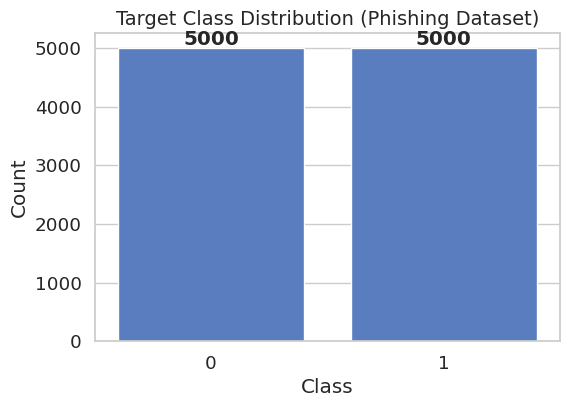

In [ ]:
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams['figure.figsize'] = (8,5)

plt.figure(figsize=(6,4))
sns.countplot(x=y_phish)
plt.title("Target Class Distribution (Phishing Dataset)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Count")
for i, v in enumerate(pd.Series(y_phish).value_counts()):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.show()



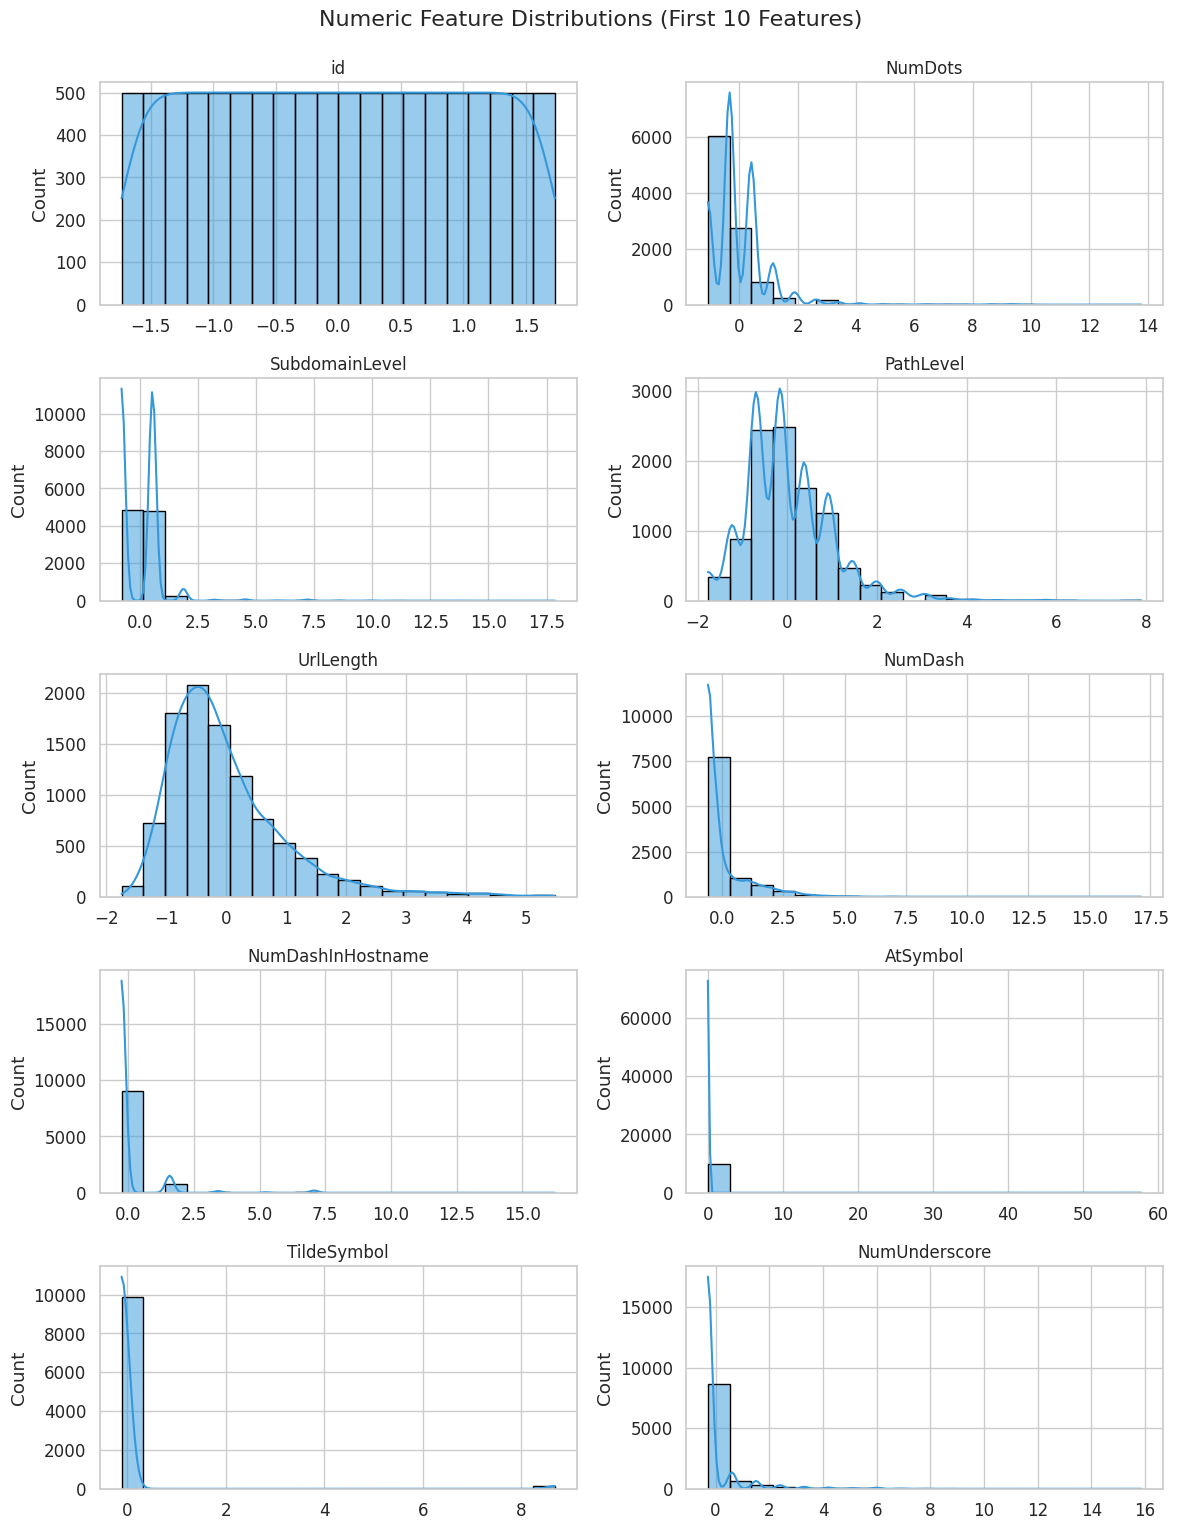

In [ ]:

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

num_features_to_plot = num_cols[:10]

fig, axes = plt.subplots(5, 2, figsize=(12, 15))
axes = axes.flatten()

for i, feature in enumerate(num_features_to_plot):
    sns.histplot(df_phish[feature], bins=20, kde=True, color="#3498db", edgecolor='black', ax=axes[i])
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Numeric Feature Distributions (First 10 Features)", fontsize=16, y=1.02)
plt.show()


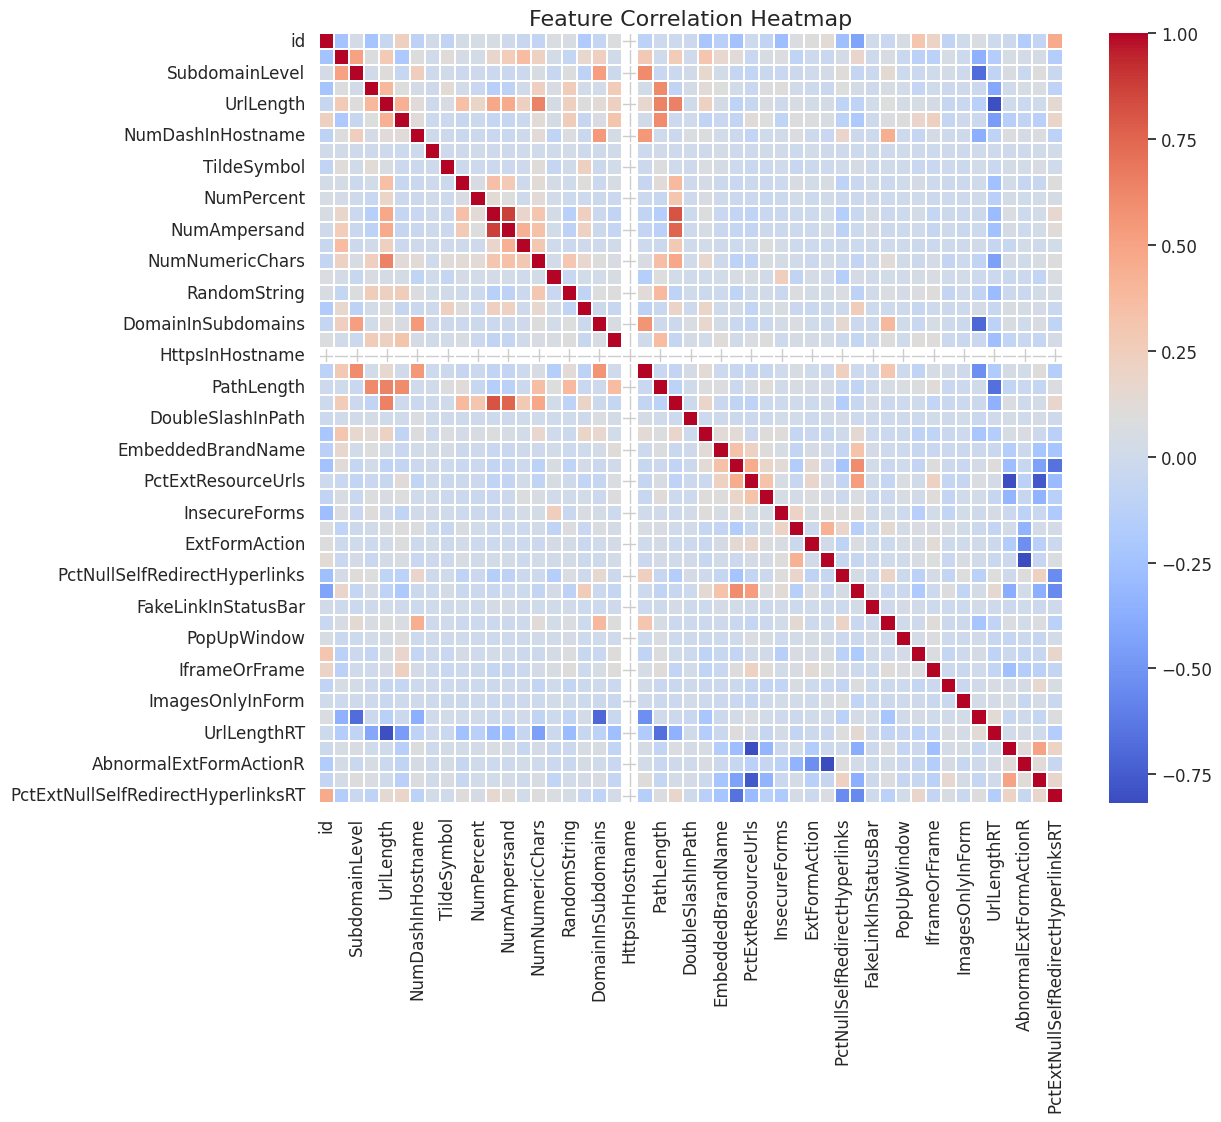

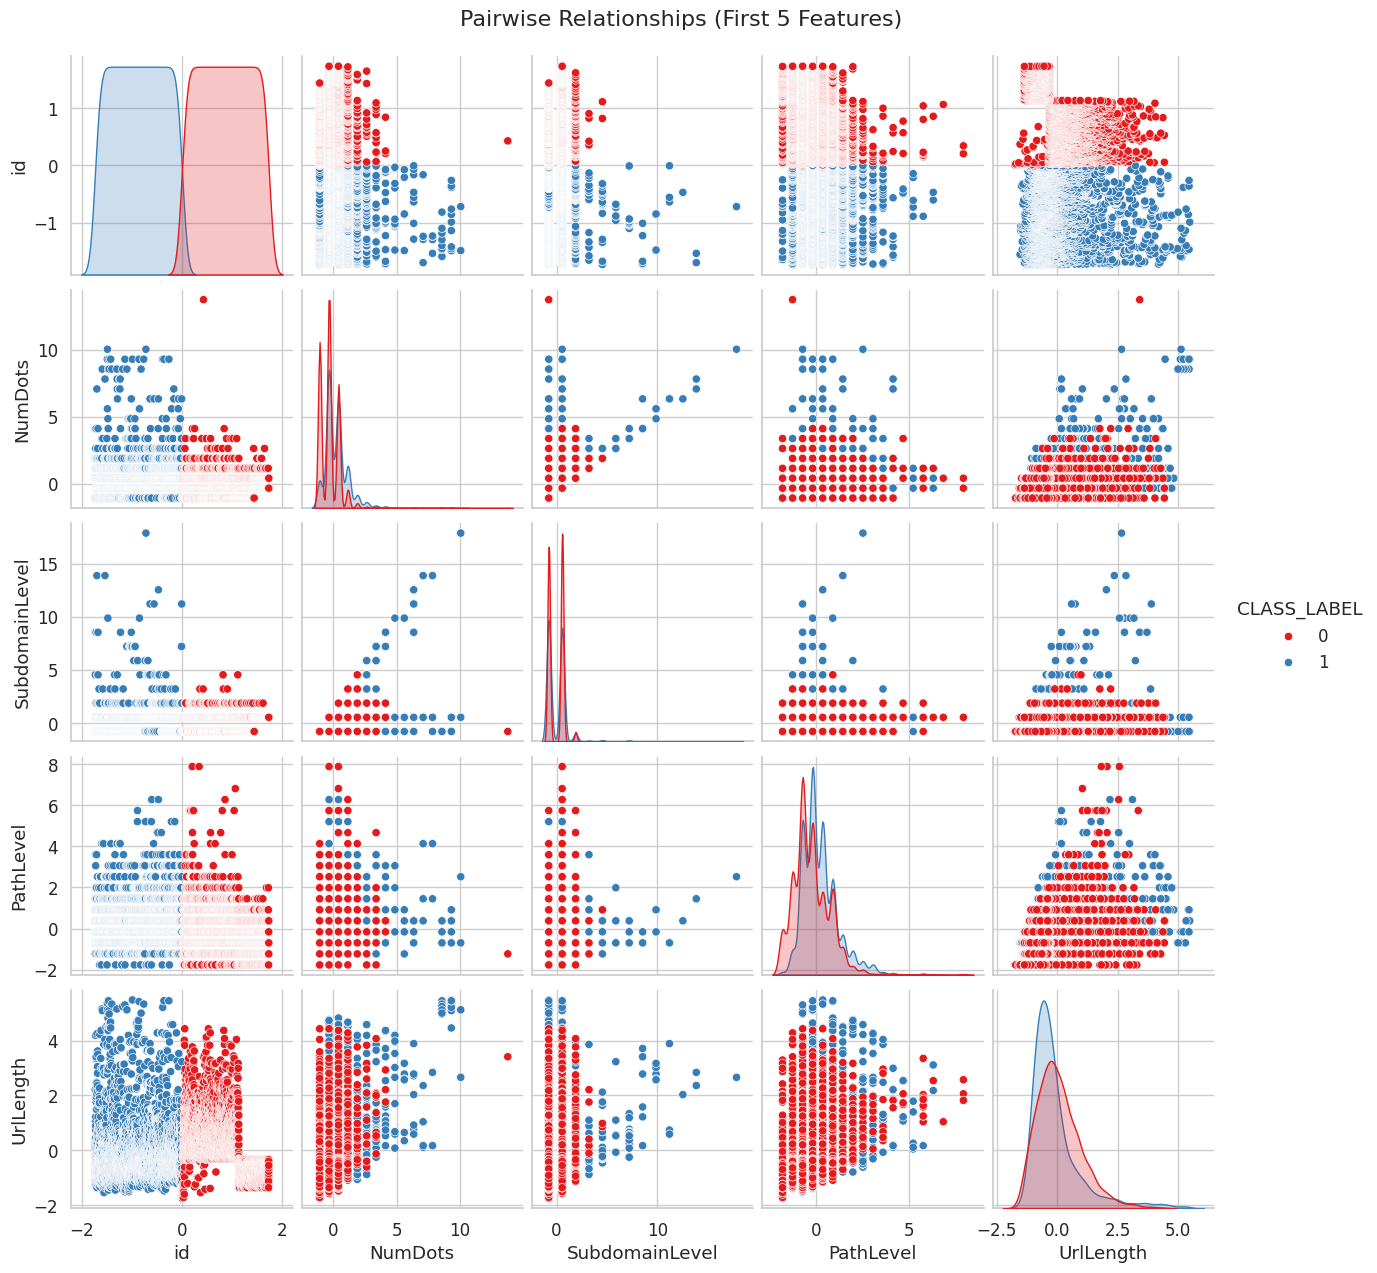

In [ ]:
plt.figure(figsize=(12,10))
corr_matrix = df_phish[num_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.2)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

pair_features = num_cols[:5] + ['CLASS_LABEL']
sns.pairplot(df_phish[pair_features], hue='CLASS_LABEL', diag_kind='kde', palette="Set1")
plt.suptitle("Pairwise Relationships (First 5 Features)", fontsize=16, y=1.02)
plt.show()

MNIST DATASET

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_all = np.vstack([X_train, X_test])
y_all = np.hstack([y_train, y_test])

print("Original shape of combined dataset:", X_all.shape, y_all.shape)

X_all_flat = X_all.reshape(X_all.shape[0], -1)

X_all_flat = X_all_flat.astype('float32') / 255.0

y_all_int = y_all


y_all_onehot = to_categorical(y_all, num_classes=10)


print("X_all_flat shape:", X_all_flat.shape)
print("y_all_int shape:", y_all_int.shape)
print("y_all_onehot shape:", y_all_onehot.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original shape of combined dataset: (70000, 28, 28) (70000,)
X_all_flat shape: (70000, 784)
y_all_int shape: (70000,)
y_all_onehot shape: (70000, 10)


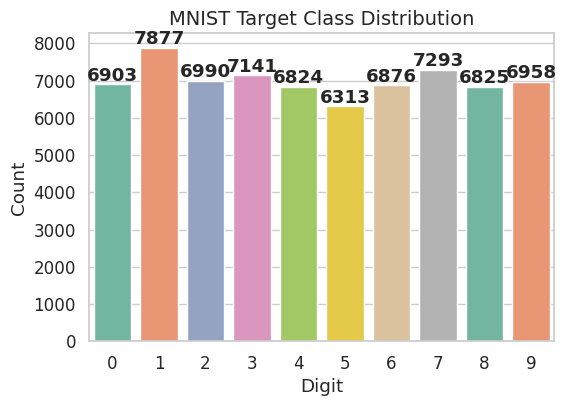

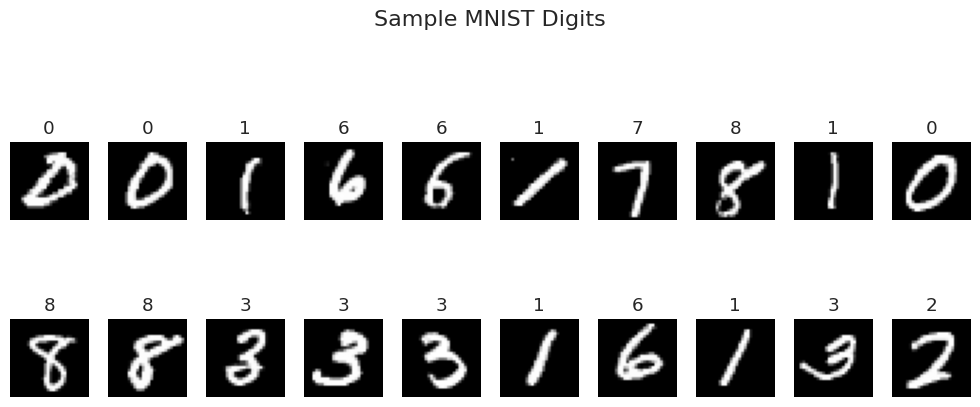

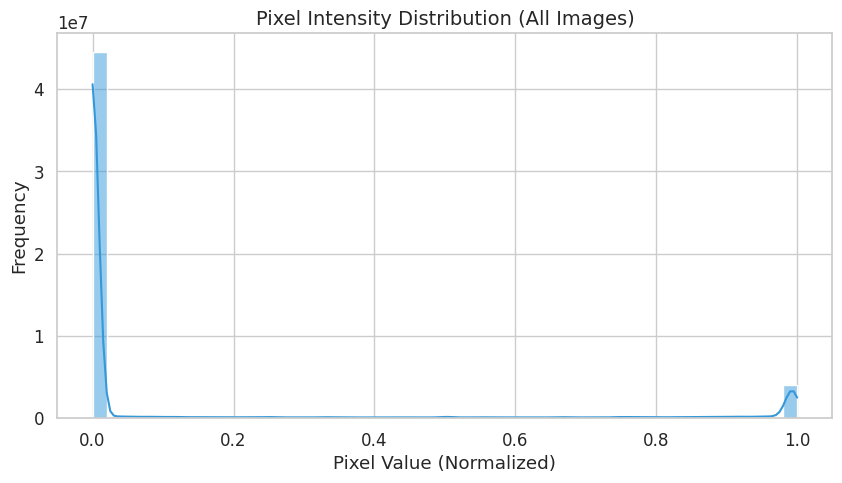

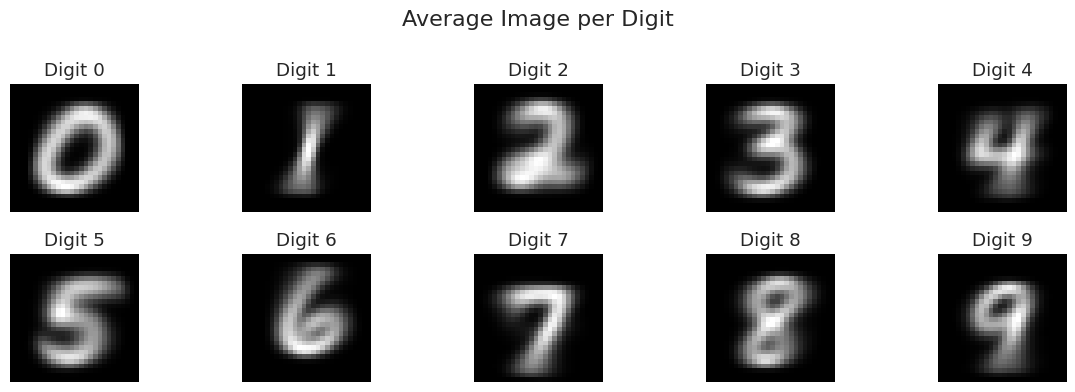

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_all_int, palette="Set2")
plt.title("MNIST Target Class Distribution", fontsize=14)
plt.xlabel("Digit")
plt.ylabel("Count")
for i, v in enumerate(np.bincount(y_all_int)):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.show()

plt.figure(figsize=(10, 5))
for i in range(20):
    idx = np.random.randint(0, X_all_flat.shape[0])
    img = X_all_flat[idx].reshape(28,28)
    plt.subplot(2, 10, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(y_all_int[idx])
plt.suptitle("Sample MNIST Digits", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(X_all_flat.flatten(), bins=50, kde=True, color="#3498db")
plt.title("Pixel Intensity Distribution (All Images)", fontsize=14)
plt.xlabel("Pixel Value (Normalized)")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(12,4))
for digit in range(10):
    plt.subplot(2,5,digit+1)
    avg_img = X_all_flat[y_all_int == digit].mean(axis=0).reshape(28,28)
    plt.imshow(avg_img, cmap='gray')
    plt.axis('off')
    plt.title(f"Digit {digit}")
plt.suptitle("Average Image per Digit", fontsize=16)
plt.tight_layout()
plt.show()

Network

In [ ]:
uploaded = files.upload()
traffic_filename = list(uploaded.keys())[0]
print("Uploaded file:", traffic_filename)
df_traffic = pd.read_csv(traffic_filename)
print("Original dataset shape:", df_traffic.shape)
df_traffic.head()

Saving UNSW_NB15_training-set.csv to UNSW_NB15_training-set.csv
Uploaded file: UNSW_NB15_training-set.csv
Original dataset shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
TARGET_SIZE = 25000

if len(df_traffic) > TARGET_SIZE:
    df_traffic = df_traffic.sample(n=TARGET_SIZE, random_state=42)
    print(f"Dataset downsampled to {TARGET_SIZE} rows")
else:
    print("Dataset size already within limit")

print("Shape after downsampling:", df_traffic.shape)


Dataset downsampled to 25000 rows
Shape after downsampling: (25000, 45)


In [ ]:
null_counts = df_traffic.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


In [ ]:
cat_cols = df_traffic.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_traffic.select_dtypes(include=['number']).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)


Categorical columns: ['proto', 'service', 'state', 'attack_cat']
Numeric columns: ['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label']


In [ ]:
print("Categorical columns and their unique values before encoding:\n")

for col in cat_cols:
    print(f"{col}: {df_traffic[col].nunique()} unique values")
    df_traffic[col] = LabelEncoder().fit_transform(df_traffic[col].astype(str))

print("\nAll categorical columns have been label-encoded.")


Categorical columns and their unique values before encoding:

proto: 132 unique values
service: 13 unique values
state: 6 unique values
attack_cat: 10 unique values

All categorical columns have been label-encoded.


In [ ]:
TARGET_COL = 'label'

le_target = LabelEncoder()
y_traffic = le_target.fit_transform(df_traffic[TARGET_COL])

print("Target classes:", le_target.classes_)
X_traffic = df_traffic.drop(columns=[TARGET_COL])
X_traffic = X_traffic.values.astype('float32')

print("Feature shape:", X_traffic.shape)
print("Target shape:", y_traffic.shape)

Target classes: [0 1]
Feature shape: (25000, 44)
Target shape: (25000,)


In [ ]:
scaler = StandardScaler()
X_traffic_scaled = scaler.fit_transform(X_traffic)

print("Feature sample after scaling:\n", X_traffic_scaled[:5])
print("Final dataset shape:", X_traffic_scaled.shape)
print("Unique target labels:", set(y_traffic))
print("Any NaNs left:", pd.isnull(X_traffic_scaled).any())


Feature sample after scaling:
 [[-1.43310928e+00  2.04643399e-01  1.44362882e-01 -7.04811752e-01
  -4.17011768e-01  1.35995674e+00  3.34025812e+00  1.69264115e-02
   3.25016069e+00 -5.69992542e-01 -1.44643772e+00 -4.60921705e-01
  -3.93457651e-01  3.89724165e-01  2.07337797e-01  3.14005017e+00
  -1.32736608e-01 -8.19228962e-02 -9.89896804e-03  6.26910746e-01
   1.08898342e+00 -3.57551783e-01 -3.55333656e-01  1.09939468e+00
  -5.25336504e-01 -4.89727676e-01 -5.12320757e-01 -3.86949301e-01
   4.39023590e+00 -1.02571592e-01 -3.88345271e-02  1.61206126e-01
  -1.36488307e+00 -1.47278041e-01 -4.21091557e-01 -5.52858651e-01
  -3.39183092e-01 -1.22740708e-01 -1.22740708e-01 -1.83517069e-01
  -3.56702656e-01  8.67563114e-02 -1.27190992e-01  8.46301973e-01]
 [ 9.00838792e-01 -2.08645552e-01  4.17777449e-01  1.64875269e-01
   7.83229351e-01 -1.21446185e-01 -1.51188582e-01 -4.92699966e-02
  -9.05473158e-02  8.87053534e-02  7.21886098e-01 -7.22860098e-01
  -1.27095744e-01 -2.77101398e-01 -7.0655241

1-ABNORMAL
0-NORMAL


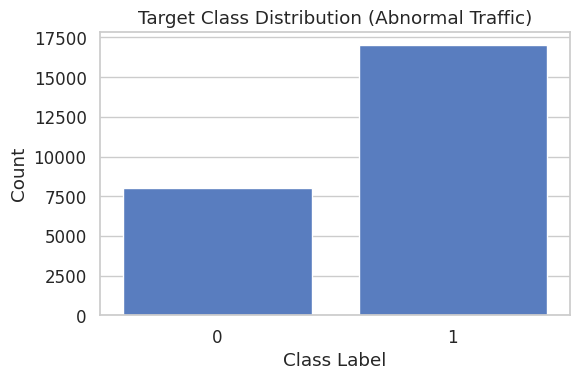

In [ ]:
print("1-ABNORMAL")
print("0-NORMAL")
plt.figure(figsize=(6,4))
sns.countplot(x=y_traffic)
plt.title("Target Class Distribution (Abnormal Traffic)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

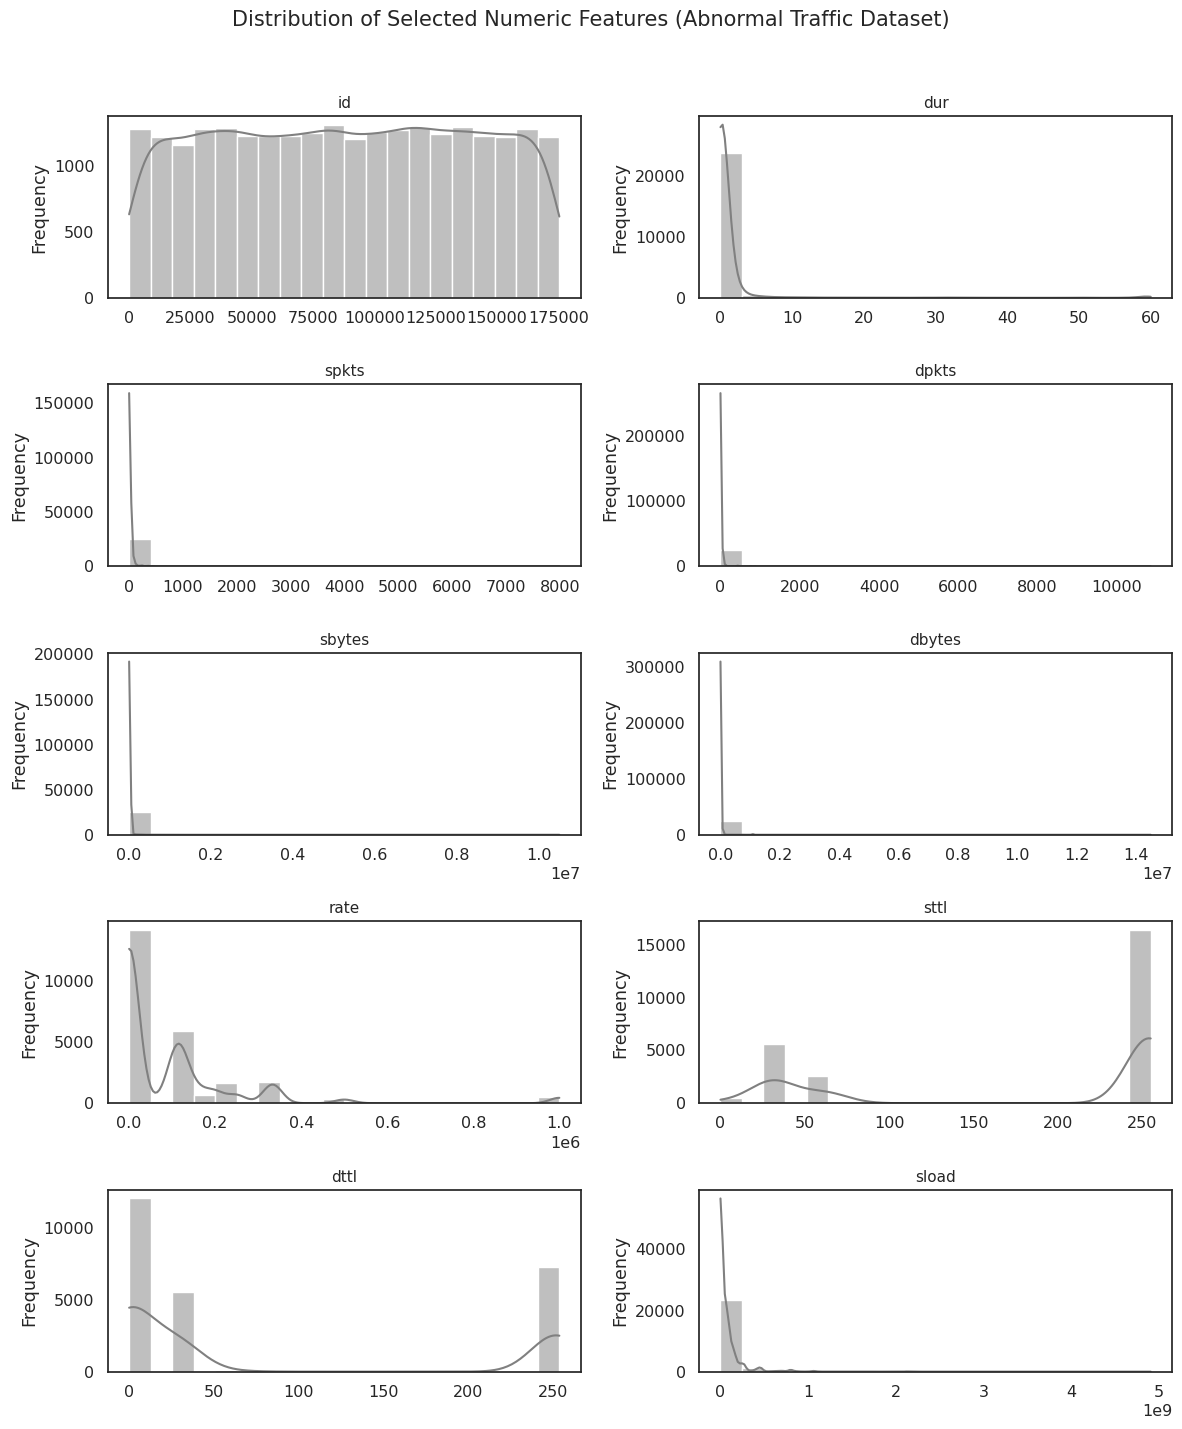

In [ ]:
sns.set(style="white", font_scale=1.05)

num_features_to_plot = num_cols[:10]

fig, axes = plt.subplots(5, 2, figsize=(12, 14))
axes = axes.flatten()

for i, feature in enumerate(num_features_to_plot):
    sns.histplot(
        df_traffic[feature],
        bins=20,
        kde=True,
        color="gray",
        edgecolor=None,
        ax=axes[i]
    )
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Remove unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Selected Numeric Features (Abnormal Traffic Dataset)",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()

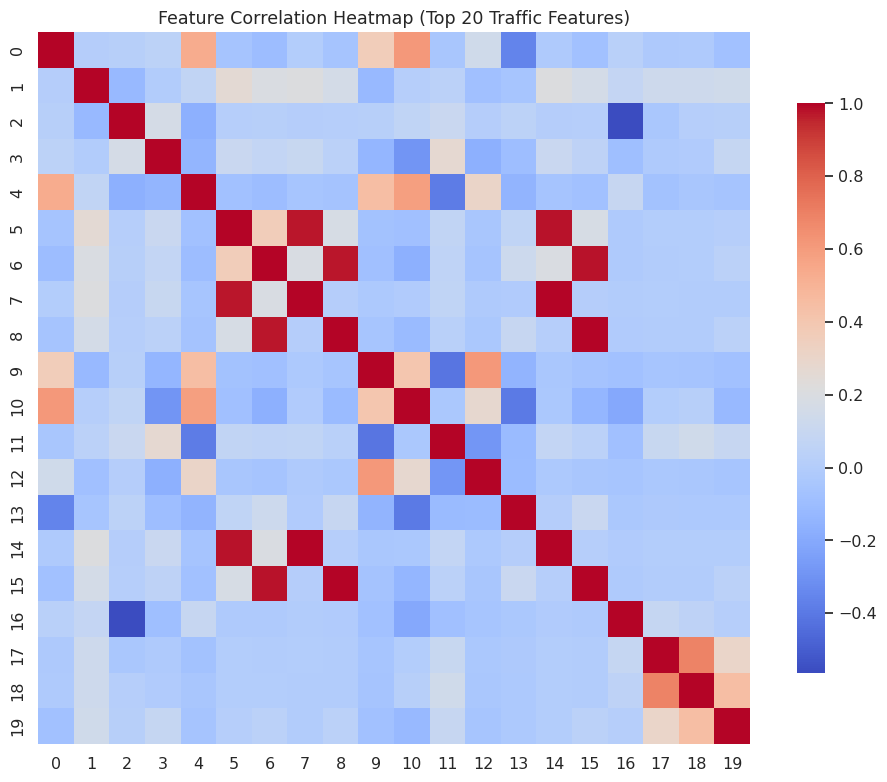

In [ ]:
corr_features = min(20, df_traffic.shape[1])

plt.figure(figsize=(10,8))
sns.heatmap(
    pd.DataFrame(X_traffic_scaled[:, :corr_features]).corr(),
    cmap='coolwarm',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title("Feature Correlation Heatmap (Top 20 Traffic Features)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

target_col = 'CLASS_LABEL'  # replace if your target column has a different name
X_phish = df_phish.drop(columns=[target_col])
y_phish = df_phish[target_col]


X_phish_train, X_phish_temp, y_phish_train, y_phish_temp = train_test_split(
    X_phish, y_phish, test_size=0.3, stratify=y_phish, random_state=42
)
X_phish_val, X_phish_test, y_phish_val, y_phish_test = train_test_split(
    X_phish_temp, y_phish_temp, test_size=0.5, stratify=y_phish_temp, random_state=42
)
X_traffic_train, X_traffic_temp, y_traffic_train, y_traffic_temp = train_test_split(
    X_traffic_scaled, y_traffic, test_size=0.3, stratify=y_traffic, random_state=42
)
X_traffic_val, X_traffic_test, y_traffic_val, y_traffic_test = train_test_split(
    X_traffic_temp, y_traffic_temp, test_size=0.5, stratify=y_traffic_temp, random_state=42
)
X_mnist_train, X_mnist_temp, y_mnist_train, y_mnist_temp = train_test_split(
    X_all_flat, y_all_int, test_size=0.3, stratify=y_all_int, random_state=42
)
X_mnist_val, X_mnist_test, y_mnist_val, y_mnist_test = train_test_split(
    X_mnist_temp, y_mnist_temp, test_size=0.5, stratify=y_mnist_temp, random_state=42
)


In [ ]:
def split_clients(X, y, num_clients=NUM_CLIENTS, alpha=0.2):
    """
    Non-IID Dirichlet split for federated training.
    Smaller alpha -> more heterogeneous clients.
    """
    X = np.array(X)
    y = np.array(y)

    num_classes = len(np.unique(y))
    class_indices = [np.where(y == i)[0] for i in range(num_classes)]

    client_indices = [[] for _ in range(num_clients)]

    for c in range(num_classes):
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (proportions * len(class_indices[c])).astype(int)

        start = 0
        for client_id, num_samples in enumerate(proportions):
            client_indices[client_id].extend(class_indices[c][start:start + num_samples])
            start += num_samples

    X_clients = [X[idx] for idx in client_indices]
    y_clients = [y[idx] for idx in client_indices]

    return X_clients, y_clients
    # Split datasets into non-IID client datasets
X_phish_clients, y_phish_clients = split_clients(X_phish, y_phish, num_clients=NUM_CLIENTS)
X_traffic_clients, y_traffic_clients = split_clients(X_traffic_scaled, y_traffic, num_clients=NUM_CLIENTS)
X_mnist_clients, y_mnist_clients = split_clients(X_all_flat, y_all_int, num_clients=NUM_CLIENTS)

In [ ]:
import tensorflow as tf

def create_client_loaders_for_task(X_clients, y_clients, test_size=0.2, batch_size=BATCH_SIZE):

    loaders = []
    for i in range(len(X_clients)):
        Xc, yc = X_clients[i], y_clients[i]

        # Convert to NumPy arrays if they are DataFrames / Series
        Xc = Xc.values if hasattr(Xc, 'values') else Xc
        yc = yc.values if hasattr(yc, 'values') else yc

        Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=test_size, random_state=42)

        train_dataset = tf.data.Dataset.from_tensor_slices((Xtr, ytr))
        train_dataset = train_dataset.shuffle(buffer_size=len(Xtr)).batch(batch_size)

        test_dataset = tf.data.Dataset.from_tensor_slices((Xte, yte))
        test_dataset = test_dataset.batch(batch_size)

        loaders.append((train_dataset, test_dataset))

    return loaders

In [ ]:
client_loaders_phish = create_client_loaders_for_task(X_phish_clients, y_phish_clients, batch_size=BATCH_SIZE)
client_loaders_traffic = create_client_loaders_for_task(X_traffic_clients, y_traffic_clients, batch_size=BATCH_SIZE)
client_loaders_mnist = create_client_loaders_for_task(X_mnist_clients, y_mnist_clients, batch_size=BATCH_SIZE)

In [ ]:
def build_global_nn(input_dim, num_classes=1, lr=1e-4):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.3),

        Dense(16, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='softmax' if num_classes > 1 else 'sigmoid')
    ])

    if num_classes > 1:
        loss_fn = 'sparse_categorical_crossentropy'
    else:
        loss_fn = 'binary_crossentropy'

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=['accuracy']
    )

    return model

# Get input dimensions from client splits
input_dim_phishing = X_phish_clients[0].shape[1]
input_dim_traffic = X_traffic_clients[0].shape[1]
input_dim_gradient = X_mnist_clients[0].shape[1]

print(f"Phishing Global Model Input Dim: {input_dim_phishing}")
print(f"Network Traffic Global Model Input Dim: {input_dim_traffic}")
print(f"Gradient Leakage (MNIST) Global Model Input Dim: {input_dim_gradient}")

# Build global models for all tasks
global_model_phishing = build_global_nn(input_dim_phishing, num_classes=1)
global_model_traffic = build_global_nn(input_dim_traffic, num_classes=1)
global_model_gradient = build_global_nn(input_dim_gradient, num_classes=10)

print("Global models created for all three tasks.")

Phishing Global Model Input Dim: 49
Network Traffic Global Model Input Dim: 44
Gradient Leakage (MNIST) Global Model Input Dim: 784
Global models created for all three tasks.


In [ ]:
def evaluate_model_on_loader(model, test_loader):
    results = model.evaluate(test_loader, verbose=0)

    if isinstance(results, list):
        loss, acc = results
    else:
        loss = results
        acc = 0.0

    total_samples = sum(1 for _ in test_loader.unbatch())

    return float(loss), float(acc), total_samples

FEDAVG++

In [ ]:
def local_train_fedavg(global_weights, train_loader, input_dim, epochs, num_classes=1, lr=1e-4):
    """
    Local training for FedAvg (supports binary & multi-class)
    """
    local_model = build_global_nn(input_dim, num_classes=num_classes, lr=lr)
    local_model.set_weights(global_weights)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = local_model.compiled_loss

    for _ in range(epochs):
        for xb, yb in train_loader:

            with tf.GradientTape() as tape:
                preds = local_model(xb, training=True)
                loss = loss_fn(yb, preds)

            grads = tape.gradient(loss, local_model.trainable_weights)
            optimizer.apply_gradients(zip(grads, local_model.trainable_weights))

    return local_model.get_weights()

In [ ]:
def aggregate_weights_fedavgpp(global_weights, client_weights_list, velocity, beta):
    """
    Server-side aggregation for FedAvg++ with momentum
    """
    new_velocity = []
    new_global_weights = []

    for gw, client_ws, v in zip(global_weights, zip(*client_weights_list), velocity):
        avg_delta = np.mean(np.array([cw - gw for cw in client_ws]), axis=0)
        v_new = beta * v + avg_delta
        w_new = gw + v_new

        new_velocity.append(v_new)A
        new_global_weights.append(w_new)

    return new_global_weights, new_velocity

In [ ]:
def federated_training_fedavgpp(global_model,
                                client_loaders,
                                input_dim,
                                num_classes,
                                local_epochs,
                                rounds=FED_ROUNDS,
                                beta=0.7):

    history = {
        'round': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    global_weights = global_model.get_weights()
    velocity = [np.zeros_like(w) for w in global_weights]

    for r in range(1, rounds + 1):
        print(f"--- Federated Round {r}/{rounds} ---")
        client_weights = []

        # ---- Local Training on Each Client ----
        for train_loader, _ in client_loaders:
            lw = local_train_fedavg(
                global_weights,
                train_loader,
                input_dim,
                epochs=local_epochs,
                num_classes=num_classes
            )
            client_weights.append(lw)

        # ---- FedAvg++ Aggregation ----
        global_weights, velocity = aggregate_weights_fedavgpp(
            global_weights,
            client_weights,
            velocity,
            beta
        )

        global_model.set_weights(global_weights)

        # ---- Evaluation ----
        train_loss_sum = train_acc_sum = train_samples = 0
        val_loss_sum = val_acc_sum = val_samples = 0

        for train_loader, _ in client_loaders:
            loss, acc, n = evaluate_model_on_loader(global_model, train_loader)
            train_loss_sum += loss * n
            train_acc_sum += acc * n
            train_samples += n

        for _, test_loader in client_loaders:
            loss, acc, n = evaluate_model_on_loader(global_model, test_loader)
            val_loss_sum += loss * n
            val_acc_sum += acc * n
            val_samples += n

        train_loss = train_loss_sum / train_samples
        train_acc = train_acc_sum / train_samples
        val_loss = val_loss_sum / val_samples
        val_acc = val_acc_sum / val_samples

        history['round'].append(r)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Round {r} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return global_model, history

In [ ]:
LOCAL_EPOCHS_PHISH = 3
LOCAL_EPOCHS_TRAFFIC = 3
LOCAL_EPOCHS_MNIST = 7


In [ ]:
def final_multi_threat_prob(phish_probs, traffic_probs):
    combined_prob = (phish_probs + traffic_probs) / 2.0
    final_flags = (combined_prob >= 0.5).astype(int)
    return final_flags

Starting federated training for PHISHING task using FedAvg++...
--- Federated Round 1/20 ---
Round 1 - Train Loss: 0.6599, Train Acc: 0.5618, Val Loss: 0.6670, Val Acc: 0.5592
--- Federated Round 2/20 ---
Round 2 - Train Loss: 0.5262, Train Acc: 0.7692, Val Loss: 0.5307, Val Acc: 0.7703
--- Federated Round 3/20 ---
Round 3 - Train Loss: 0.3562, Train Acc: 0.9106, Val Loss: 0.3570, Val Acc: 0.9131
--- Federated Round 4/20 ---
Round 4 - Train Loss: 0.2144, Train Acc: 0.9592, Val Loss: 0.2136, Val Acc: 0.9616
--- Federated Round 5/20 ---
Round 5 - Train Loss: 0.1347, Train Acc: 0.9631, Val Loss: 0.1324, Val Acc: 0.9626
--- Federated Round 6/20 ---
Round 6 - Train Loss: 0.1012, Train Acc: 0.9651, Val Loss: 0.0976, Val Acc: 0.9661
--- Federated Round 7/20 ---
Round 7 - Train Loss: 0.0858, Train Acc: 0.9692, Val Loss: 0.0818, Val Acc: 0.9690
--- Federated Round 8/20 ---
Round 8 - Train Loss: 0.0720, Train Acc: 0.9750, Val Loss: 0.0684, Val Acc: 0.9750
--- Federated Round 9/20 ---
Round 9 - T

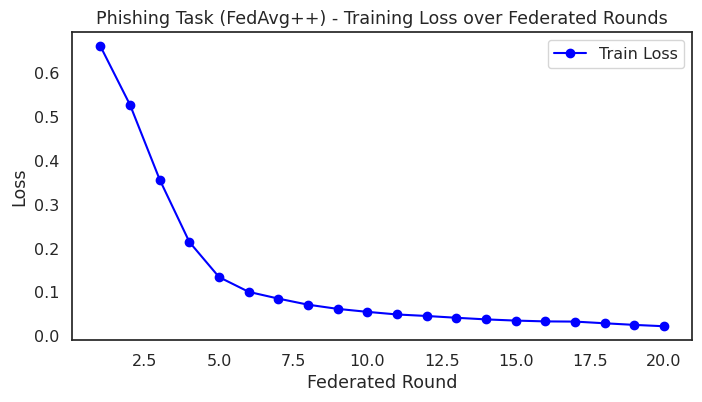

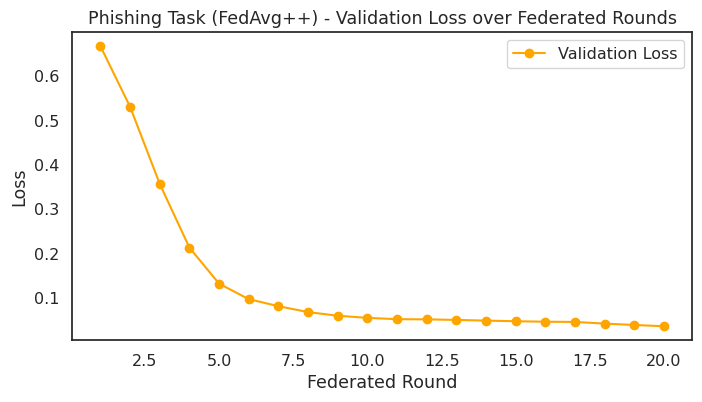

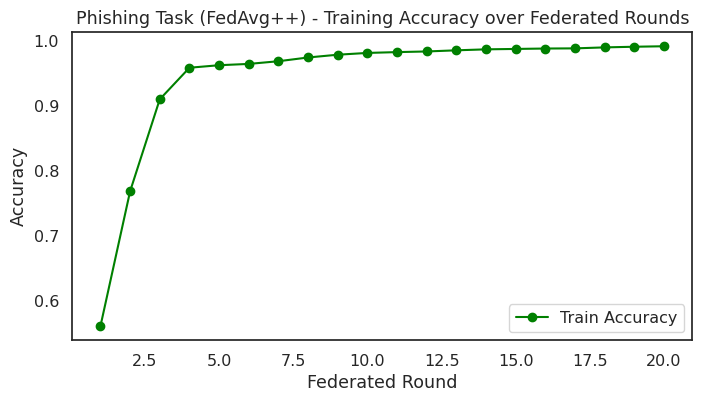

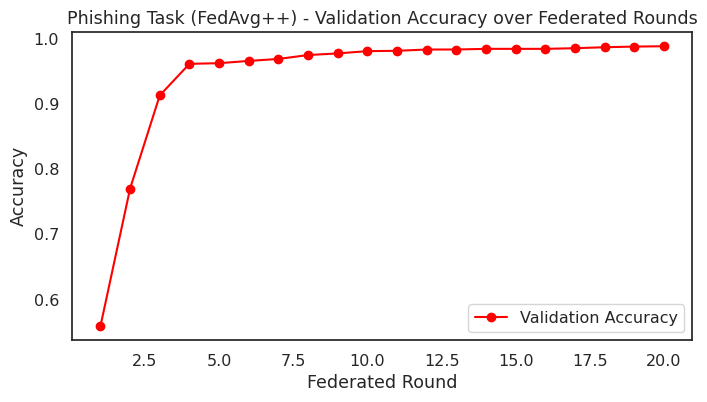

In [ ]:
print("Starting federated training for PHISHING task using FedAvg++...")

global_model_phishing_trained, hist_phishing = federated_training_fedavgpp(
    global_model_phishing,
    client_loaders_phish,
    input_dim_phishing,
    num_classes=1,  # <-- FIX ADDED (binary task)
    local_epochs=LOCAL_EPOCHS_PHISH,
    rounds=FED_ROUNDS,
    beta=0.7
)

plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['train_loss'], label='Train Loss', color='blue', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Phishing Task (FedAvg++) - Training Loss over Federated Rounds')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Phishing Task (FedAvg++) - Validation Loss over Federated Rounds')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['train_acc'], label='Train Accuracy', color='green', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Phishing Task (FedAvg++) - Training Accuracy over Federated Rounds')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['val_acc'], label='Validation Accuracy', color='red', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Phishing Task (FedAvg++) - Validation Accuracy over Federated Rounds')
plt.legend()
plt.show()

In [ ]:
print("Evaluating trained global model for PHISHING task...")

all_test_losses = []
all_test_accs = []
all_test_samples = 0

for client_idx, (train_loader, test_loader) in enumerate(client_loaders_phish):
    loss, acc, n_samples = evaluate_model_on_loader(global_model_phishing_trained, test_loader)
    all_test_losses.append(loss * n_samples)
    all_test_accs.append(acc * n_samples)
    all_test_samples += n_samples
    print(f"Client {client_idx} - Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}, Samples: {n_samples}")

test_loss = sum(all_test_losses) / all_test_samples if all_test_samples > 0 else 0.0
test_acc = sum(all_test_accs) / all_test_samples if all_test_samples > 0 else 0.0
print(f"\nOverall PHISHING Task - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


X_test_samples = []
y_test_samples = []

for _, test_loader in client_loaders_phish:
    for xb, yb in test_loader:
        X_test_samples.append(xb)   # <-- removed .numpy()
        y_test_samples.append(yb)   # <-- removed .numpy()

X_test_samples = tf.concat(X_test_samples, axis=0)
y_test_samples = tf.concat(y_test_samples, axis=0)

phish_probs = global_model_phishing_trained.predict(X_test_samples).flatten()

threshold = 0.5
phish_flags = (phish_probs >= threshold).astype(int)

print("\nSample predictions (0=Safe, 1=Malicious):")
for i in range(min(10, len(phish_flags))):
    print(f"True: {int(y_test_samples[i])}, Predicted: {phish_flags[i]}")

Evaluating trained global model for PHISHING task...
Client 0 - Test Loss: 0.0892, Test Accuracy: 0.9744, Samples: 585
Client 1 - Test Loss: 0.0005, Test Accuracy: 1.0000, Samples: 574
Client 2 - Test Loss: 0.0070, Test Accuracy: 0.9963, Samples: 272
Client 3 - Test Loss: 0.0000, Test Accuracy: 1.0000, Samples: 180
Client 4 - Test Loss: 0.0489, Test Accuracy: 0.9819, Samples: 386
Client 5 - Test Loss: 0.0000, Test Accuracy: 1.0000, Samples: 6

Overall PHISHING Task - Test Loss: 0.0366, Test Accuracy: 0.9885
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Sample predictions (0=Safe, 1=Malicious):
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0


Starting federated training for NETWORK TRAFFIC task using FedAvg++...
--- Federated Round 1/20 ---
Round 1 - Train Loss: 0.6091, Train Acc: 0.7450, Val Loss: 0.6127, Val Acc: 0.7378
--- Federated Round 2/20 ---
Round 2 - Train Loss: 0.5105, Train Acc: 0.7260, Val Loss: 0.5088, Val Acc: 0.7290
--- Federated Round 3/20 ---
Round 3 - Train Loss: 0.5110, Train Acc: 0.7176, Val Loss: 0.5036, Val Acc: 0.7226
--- Federated Round 4/20 ---
Round 4 - Train Loss: 0.5852, Train Acc: 0.7254, Val Loss: 0.5755, Val Acc: 0.7300
--- Federated Round 5/20 ---
Round 5 - Train Loss: 0.5557, Train Acc: 0.7580, Val Loss: 0.5476, Val Acc: 0.7617
--- Federated Round 6/20 ---
Round 6 - Train Loss: 0.4245, Train Acc: 0.8269, Val Loss: 0.4200, Val Acc: 0.8275
--- Federated Round 7/20 ---
Round 7 - Train Loss: 0.2587, Train Acc: 0.9045, Val Loss: 0.2581, Val Acc: 0.9033
--- Federated Round 8/20 ---
Round 8 - Train Loss: 0.1817, Train Acc: 0.9298, Val Loss: 0.1834, Val Acc: 0.9316
--- Federated Round 9/20 ---
Roun

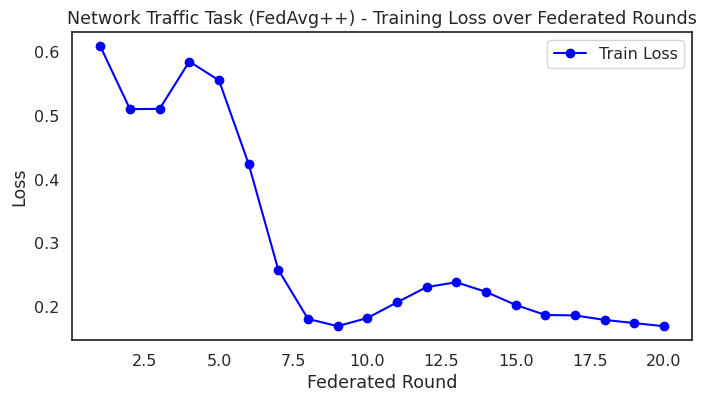

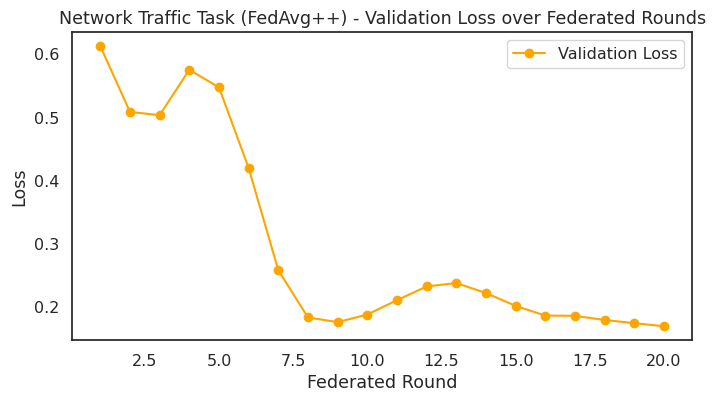

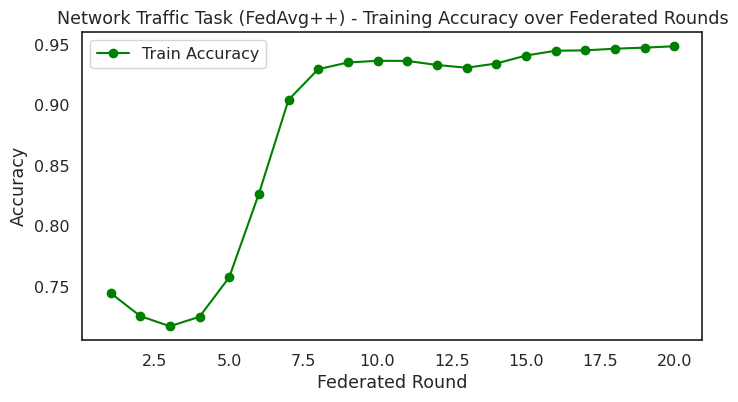

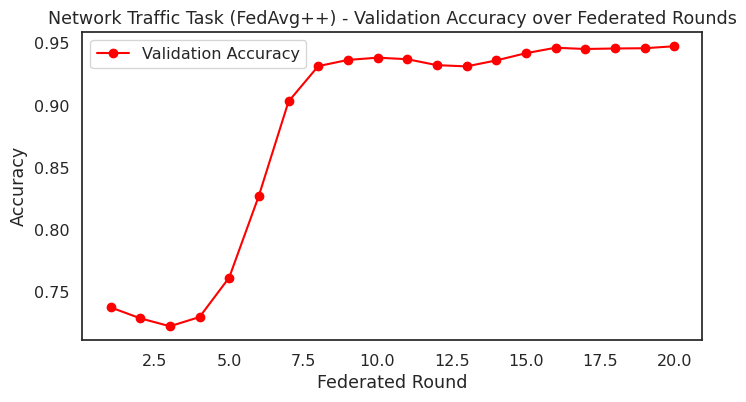

In [ ]:
print("Starting federated training for NETWORK TRAFFIC task using FedAvg++...")

global_model_traffic_trained, hist_traffic = federated_training_fedavgpp(
    global_model_traffic,
    client_loaders_traffic,
    input_dim_traffic,
    num_classes=1,  # <-- FIX ADDED (binary task)
    local_epochs=LOCAL_EPOCHS_TRAFFIC,
    rounds=FED_ROUNDS,
    beta=0.7
)

plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['train_loss'], label='Train Loss', color='blue', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Network Traffic Task (FedAvg++) - Training Loss over Federated Rounds')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Network Traffic Task (FedAvg++) - Validation Loss over Federated Rounds')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['train_acc'], label='Train Accuracy', color='green', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Network Traffic Task (FedAvg++) - Training Accuracy over Federated Rounds')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['val_acc'], label='Validation Accuracy', color='red', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Network Traffic Task (FedAvg++) - Validation Accuracy over Federated Rounds')
plt.legend()
plt.show()

In [ ]:
print("Evaluating trained global model for NETWORK TRAFFIC task...")

# Collect all test samples from clients
X_test_samples = []
y_test_samples = []

for _, test_loader in client_loaders_traffic:
    for xb, yb in test_loader:
        # Convert tensors to compatible type if needed
        X_test_samples.append(xb)  # no .numpy(), keep as TensorFlow tensors
        y_test_samples.append(yb)

X_test_samples = tf.concat(X_test_samples, axis=0)
y_test_samples = tf.concat(y_test_samples, axis=0)

# Evaluate the global model
test_loss, test_acc, total_samples = evaluate_model_on_loader(global_model_traffic_trained,
                                                              tf.data.Dataset.from_tensor_slices((X_test_samples, y_test_samples)).batch(256))

print(f"Overall NETWORK TRAFFIC Task - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Get probability predictions
traffic_probs = global_model_traffic_trained.predict(X_test_samples).flatten()

# Convert probabilities to binary predictions
threshold = 0.5
traffic_flags = (traffic_probs >= threshold).astype(int)

# Print sample predictions
print("\nSample predictions (0=Safe, 1=Malicious):")
for i in range(min(10, len(traffic_flags))):
    print(f"True: {int(y_test_samples[i])}, Predicted: {traffic_flags[i]}")

# Show prediction distribution
unique, counts = np.unique(traffic_flags, return_counts=True)
print("\nPredicted class distribution:", dict(zip(unique, counts)))

Evaluating trained global model for NETWORK TRAFFIC task...
Overall NETWORK TRAFFIC Task - Test Loss: 0.1694, Test Accuracy: 0.9476
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Sample predictions (0=Safe, 1=Malicious):
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1

Predicted class distribution: {np.int64(0): np.int64(1805), np.int64(1): np.int64(3198)}


In [ ]:
import numpy as np

def compute_gradient_norm(delta):
    """L2 norm of client update"""
    return np.sqrt(sum(np.sum(d**2) for d in delta))


def compute_gradient_variance(client_deltas):
    """Variance of client gradient updates"""
    stacked = [np.concatenate([d.flatten() for d in delta]) for delta in client_deltas]
    return np.var(np.stack(stacked), axis=0).mean()


def reconstruction_vulnerability_proxy(grad_norm, grad_var):
    """Simple proxy for gradient inversion vulnerability"""
    return grad_norm * grad_var


In [ ]:
def federated_training_fedavgpp_gradient_metrics(
    global_model,
    client_loaders,
    input_dim,
    num_classes,
    local_epochs,
    rounds=FED_ROUNDS,
    beta=0.9
):
    """
    FedAvg++ training with gradient leakage metrics (MNIST)
    """

    history = {
        'round': [],
        'grad_norm': [],
        'grad_variance': [],
        'sudden_divergence': [],
        'recon_vulnerability': []
    }

    global_weights = global_model.get_weights()
    velocity = [np.zeros_like(w) for w in global_weights]

    prev_grad_norm = None

    for r in range(1, rounds + 1):
        print(f"--- FedAvg++ Round {r}/{rounds} ---")

        client_deltas = []
        grad_norms = []

        # ---- Local training on each client ----
        for train_loader, _ in client_loaders:
            # Using the correct function name
            updated_weights = local_train_fedavg(
                global_weights,
                train_loader,
                input_dim=input_dim,
                epochs=local_epochs,
                num_classes=num_classes
            )
            # Delta = client update - global weights
            delta = [uw - gw for uw, gw in zip(updated_weights, global_weights)]
            client_deltas.append(delta)
            grad_norms.append(compute_gradient_norm(delta))

        # ---- FedAvg++ aggregation with momentum ----
        global_weights, velocity = aggregate_weights_fedavgpp(
            global_weights,
            [ [gw + d for gw, d in zip(global_weights, delta)] for delta in client_deltas],
            velocity,
            beta
        )
        global_model.set_weights(global_weights)

        avg_grad_norm = np.mean(grad_norms)
        grad_variance = compute_gradient_variance(client_deltas)

        sudden_div = 0.0 if prev_grad_norm is None else abs(avg_grad_norm - prev_grad_norm)
        recon_proxy = reconstruction_vulnerability_proxy(avg_grad_norm, grad_variance)

        prev_grad_norm = avg_grad_norm

        # Record metrics
        history['round'].append(r)
        history['grad_norm'].append(avg_grad_norm)
        history['grad_variance'].append(grad_variance)
        history['sudden_divergence'].append(sudden_div)
        history['recon_vulnerability'].append(recon_proxy)

        print(
            f"Round {r} | "
            f"Grad Norm: {avg_grad_norm:.4f}, "
            f"Grad Var: {grad_variance:.6f}, "
            f"Divergence: {sudden_div:.4f}, "
            f"Recon Risk: {recon_proxy:.6f}"
        )

    return global_model, history

In [ ]:
print("Starting federated training for GRADIENT LEAKAGE (MNIST) task using FedAvg++...")

global_model_gradient_trained, hist_mnist = federated_training_fedavgpp_gradient_metrics(
    global_model_gradient,
    client_loaders_mnist,
    input_dim_gradient,
    num_classes=10,              # ← ADD THIS
    local_epochs=LOCAL_EPOCHS_MNIST,
    rounds=FED_ROUNDS,
    beta=0.9
)

Starting federated training for GRADIENT LEAKAGE (MNIST) task using FedAvg++...
--- FedAvg++ Round 1/20 ---
Round 1 | Grad Norm: 4.2147, Grad Var: 0.000139, Divergence: 0.0000, Recon Risk: 0.000584
--- FedAvg++ Round 2/20 ---
Round 2 | Grad Norm: 3.3089, Grad Var: 0.000089, Divergence: 0.9058, Recon Risk: 0.000296
--- FedAvg++ Round 3/20 ---
Round 3 | Grad Norm: 2.4722, Grad Var: 0.000054, Divergence: 0.8367, Recon Risk: 0.000132
--- FedAvg++ Round 4/20 ---
Round 4 | Grad Norm: 2.2289, Grad Var: 0.000038, Divergence: 0.2433, Recon Risk: 0.000084
--- FedAvg++ Round 5/20 ---
Round 5 | Grad Norm: 2.0140, Grad Var: 0.000033, Divergence: 0.2149, Recon Risk: 0.000067
--- FedAvg++ Round 6/20 ---
Round 6 | Grad Norm: 1.8923, Grad Var: 0.000032, Divergence: 0.1217, Recon Risk: 0.000061
--- FedAvg++ Round 7/20 ---
Round 7 | Grad Norm: 1.9372, Grad Var: 0.000032, Divergence: 0.0449, Recon Risk: 0.000062
--- FedAvg++ Round 8/20 ---
Round 8 | Grad Norm: 1.8885, Grad Var: 0.000030, Divergence: 0.048

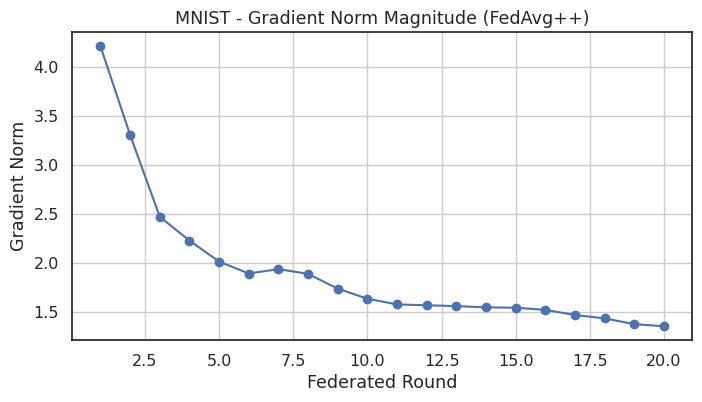

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist['round'], hist_mnist['grad_norm'], marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Gradient Norm')
plt.title('MNIST - Gradient Norm Magnitude (FedAvg++)')
plt.grid(True)
plt.show()


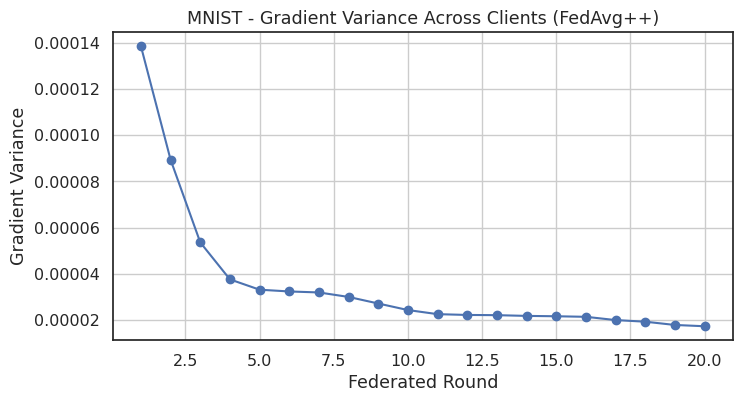

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist['round'], hist_mnist['grad_variance'], marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Gradient Variance')
plt.title('MNIST - Gradient Variance Across Clients (FedAvg++)')
plt.grid(True)
plt.show()


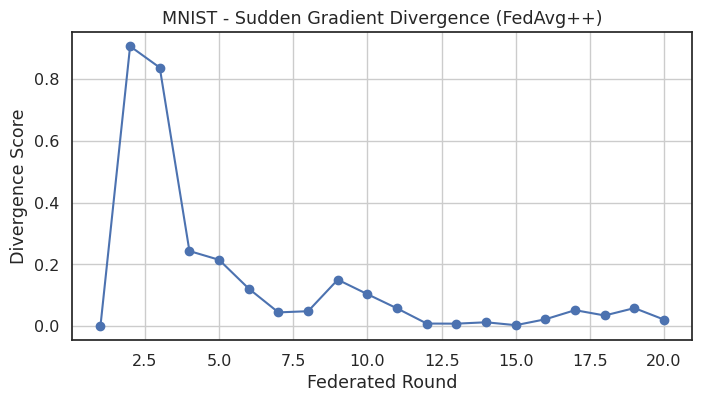

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist['round'], hist_mnist['sudden_divergence'], marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Divergence Score')
plt.title('MNIST - Sudden Gradient Divergence (FedAvg++)')
plt.grid(True)
plt.show()


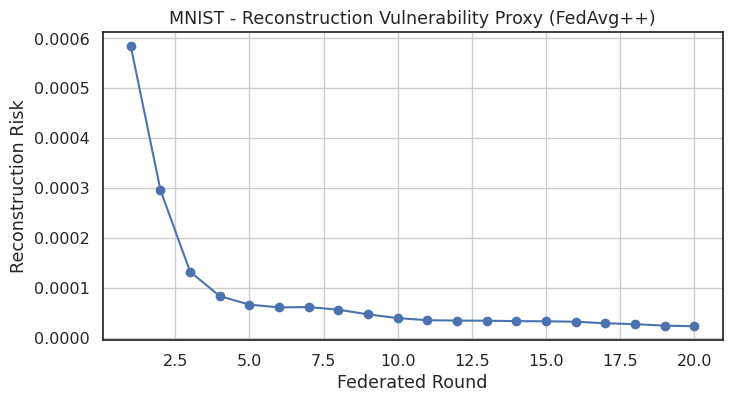

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist['round'], hist_mnist['recon_vulnerability'], marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Reconstruction Risk')
plt.title('MNIST - Reconstruction Vulnerability Proxy (FedAvg++)')
plt.grid(True)
plt.show()


In [ ]:
mnist_probs = global_model_gradient_trained.predict(X_test_mnist)

# Take class with highest probability
mnist_preds = np.argmax(mnist_probs, axis=1)

print("\nSample predictions (0–9 classes):")
for i in range(min(10, len(mnist_preds))):
    print(f"True: {y_test_mnist[i]}, Predicted: {mnist_preds[i]}")

unique, counts = np.unique(mnist_preds, return_counts=True)
print("\nPredicted class distribution:", dict(zip(unique, counts)))

NameError: name 'X_test_mnist' is not defined

In [ ]:
print("Evaluating trained global model for GRADIENT LEAKAGE (MNIST) task...")

# Collect all test samples from clients
X_test_samples = []
y_test_samples = []

for _, test_loader in client_loaders_mnist:
    for xb, yb in test_loader:
        X_test_samples.append(xb)  # keep as TF tensors
        y_test_samples.append(yb)

X_test_samples = tf.concat(X_test_samples, axis=0)
y_test_samples = tf.concat(y_test_samples, axis=0)

# Evaluate the global model
test_loss, test_acc, total_samples = evaluate_model_on_loader(
    global_model_gradient_trained,
    tf.data.Dataset.from_tensor_slices((X_test_samples, y_test_samples)).batch(256)
)

print(f"Overall MNIST Task - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Multiclass prediction
mnist_probs = global_model_gradient_trained.predict(X_test_samples)
mnist_preds = np.argmax(mnist_probs, axis=1)

print("\nSample predictions (0–9 classes):")
for i in range(min(10, len(mnist_preds))):
    print(f"True: {int(y_test_samples[i])}, Predicted: {mnist_preds[i]}")

# Predicted class distribution
unique, counts = np.unique(mnist_preds, return_counts=True)
print("\nPredicted class distribution:", dict(zip(unique, counts)))

Evaluating trained global model for GRADIENT LEAKAGE (MNIST) task...
Overall MNIST Task - Test Loss: 0.1818, Test Accuracy: 0.9667
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Sample predictions (0–9 classes):
True: 3, Predicted: 3
True: 9, Predicted: 9
True: 8, Predicted: 8
True: 4, Predicted: 4
True: 3, Predicted: 3
True: 3, Predicted: 3
True: 9, Predicted: 9
True: 9, Predicted: 9
True: 3, Predicted: 3
True: 8, Predicted: 8

Predicted class distribution: {np.int64(0): np.int64(1473), np.int64(1): np.int64(1539), np.int64(2): np.int64(1418), np.int64(3): np.int64(1402), np.int64(4): np.int64(1372), np.int64(5): np.int64(1200), np.int64(6): np.int64(1392), np.int64(7): np.int64(1466), np.int64(8): np.int64(1335), np.int64(9): np.int64(1401)}


In [ ]:
print("Performing FINAL SYSTEM-LEVEL SAFETY EVALUATION (FedAvg++)...")

# --- Threat Detection ---
phish_attack_detected = np.any(phish_flags == 1)
traffic_attack_detected = np.any(traffic_flags == 1)

# --- Gradient Leakage Risk from MNIST ---
final_recon_risk = hist_mnist['recon_vulnerability'][-1]
RECON_RISK_THRESHOLD = 0.01
mnist_attack_detected = final_recon_risk > RECON_RISK_THRESHOLD

print("\nThreat Detection Summary:")
print(f"Phishing Threat Detected: {phish_attack_detected}")
print(f"Traffic Threat Detected: {traffic_attack_detected}")
print(
    f"Gradient Leakage Detected: {mnist_attack_detected} "
    f"(Recon Risk = {final_recon_risk:.6f})"
)

# --- Final System Status ---
if phish_attack_detected or traffic_attack_detected or mnist_attack_detected:
    final_system_status = "UNSAFE"
else:
    final_system_status = "SAFE"

print("\n==============================")
print(f"FINAL SYSTEM STATUS: {final_system_status}")

Performing FINAL SYSTEM-LEVEL SAFETY EVALUATION (FedAvg++)...

Threat Detection Summary:
Phishing Threat Detected: True
Traffic Threat Detected: True
Gradient Leakage Detected: False (Recon Risk = 0.000023)

FINAL SYSTEM STATUS: UNSAFE


FEDPROX


In [ ]:
LOCAL_EPOCHS_PHISH = 3
LOCAL_EPOCHS_TRAFFIC = 3
LOCAL_EPOCHS_MNIST = 7


In [ ]:
def local_train_fedprox(global_weights, train_loader, input_dim, epochs, num_classes=1, lr=1e-4, mu=0.001):
    """
    Local training for FedProx (supports binary & multi-class)
    """
    local_model = build_global_nn(input_dim, num_classes=num_classes, lr=lr)
    local_model.set_weights(global_weights)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = local_model.compiled_loss

    # Convert global weights to tensors once
    global_weights_tensor = [tf.convert_to_tensor(w) for w in global_weights]

    for _ in range(epochs):
        for xb, yb in train_loader:

            with tf.GradientTape() as tape:
                preds = local_model(xb, training=True)
                base_loss = loss_fn(yb, preds)

                # ---- FedProx proximal term ----
                prox_term = 0.0
                for w, w_global in zip(local_model.trainable_weights, global_weights_tensor):
                    prox_term += tf.reduce_sum(tf.square(w - w_global))

                loss = base_loss + (mu / 2.0) * prox_term
                # -------------------------------

            grads = tape.gradient(loss, local_model.trainable_weights)
            optimizer.apply_gradients(zip(grads, local_model.trainable_weights))

    return local_model.get_weights()

In [ ]:
def aggregate_weights_fedprox(client_weights_list):
    """
    Server-side aggregation for FedProx (FedAvg-style averaging)
    """
    new_weights = []
    for weights in zip(*client_weights_list):
        new_weights.append(np.mean(np.array(weights), axis=0))
    return new_weights

In [ ]:
def federated_training_fedprox(global_model,
                               client_loaders,
                               input_dim,
                               num_classes,
                               local_epochs,
                               rounds=FED_ROUNDS,
                               mu=0.001):

    history = {
        'round': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    global_weights = global_model.get_weights()

    for r in range(1, rounds + 1):
        print(f"--- FedProx Round {r}/{rounds} ---")
        client_weights = []

        # ---- Local Training on Each Client ----
        for train_loader, _ in client_loaders:
            lw = local_train_fedprox(
                global_weights,
                train_loader,
                input_dim,
                epochs=local_epochs,
                num_classes=num_classes,
                mu=mu
            )
            client_weights.append(lw)

        # ---- FedProx Aggregation (FedAvg-style) ----
        global_weights = aggregate_weights_fedprox(client_weights)
        global_model.set_weights(global_weights)

        # ---- Evaluation (IDENTICAL to FedAvg++) ----
        train_loss_sum = train_acc_sum = train_samples = 0
        val_loss_sum = val_acc_sum = val_samples = 0

        for train_loader, _ in client_loaders:
            loss, acc, n = evaluate_model_on_loader(global_model, train_loader)
            train_loss_sum += loss * n
            train_acc_sum += acc * n
            train_samples += n

        for _, test_loader in client_loaders:
            loss, acc, n = evaluate_model_on_loader(global_model, test_loader)
            val_loss_sum += loss * n
            val_acc_sum += acc * n
            val_samples += n

        train_loss = train_loss_sum / train_samples
        train_acc = train_acc_sum / train_samples
        val_loss = val_loss_sum / val_samples
        val_acc = val_acc_sum / val_samples

        history['round'].append(r)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Round {r} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return global_model, history

Starting federated training for PHISHING task...
--- FedProx Round 1/20 ---
Round 1 - Train Loss: 0.6414, Train Acc: 0.6549, Val Loss: 0.6374, Val Acc: 0.6622
--- FedProx Round 2/20 ---
Round 2 - Train Loss: 0.5557, Train Acc: 0.8174, Val Loss: 0.5534, Val Acc: 0.8196
--- FedProx Round 3/20 ---
Round 3 - Train Loss: 0.4758, Train Acc: 0.9026, Val Loss: 0.4736, Val Acc: 0.9035
--- FedProx Round 4/20 ---
Round 4 - Train Loss: 0.4058, Train Acc: 0.9281, Val Loss: 0.4029, Val Acc: 0.9275
--- FedProx Round 5/20 ---
Round 5 - Train Loss: 0.3453, Train Acc: 0.9332, Val Loss: 0.3409, Val Acc: 0.9375
--- FedProx Round 6/20 ---
Round 6 - Train Loss: 0.2967, Train Acc: 0.9347, Val Loss: 0.2904, Val Acc: 0.9410
--- FedProx Round 7/20 ---
Round 7 - Train Loss: 0.2581, Train Acc: 0.9357, Val Loss: 0.2493, Val Acc: 0.9445
--- FedProx Round 8/20 ---
Round 8 - Train Loss: 0.2281, Train Acc: 0.9376, Val Loss: 0.2170, Val Acc: 0.9445
--- FedProx Round 9/20 ---
Round 9 - Train Loss: 0.2039, Train Acc: 0.9

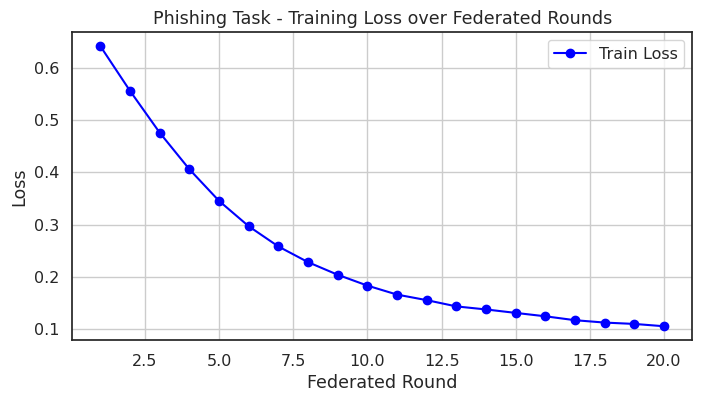

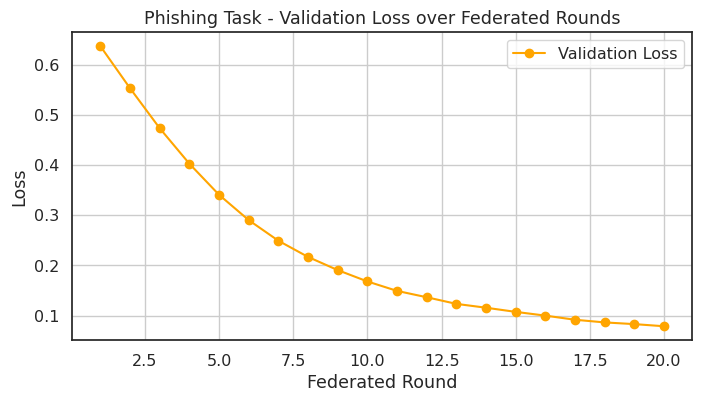

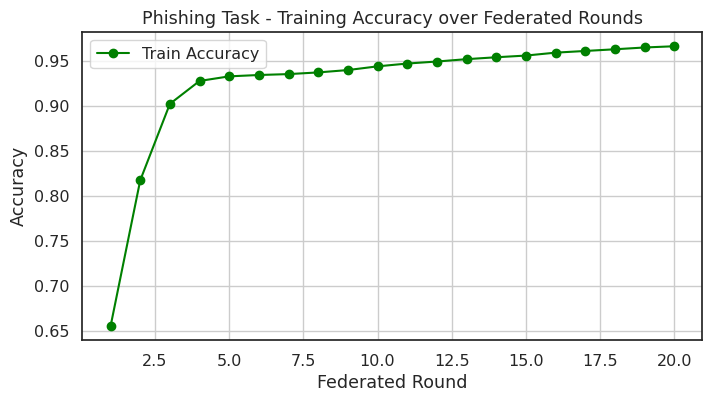

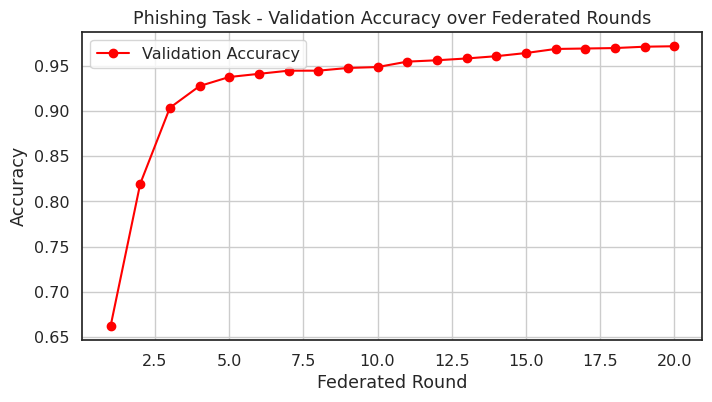

In [ ]:
print("Starting federated training for PHISHING task...")

# Run federated training for phishing
global_model_phishing_trained, hist_phishing = federated_training_fedprox(
    global_model=global_model_phishing,
    client_loaders=client_loaders_phish,
    input_dim=input_dim_phishing,
    local_epochs=LOCAL_EPOCHS_PHISH,
    num_classes=1,          # ✅ Added (binary task)
    rounds=FED_ROUNDS,
    mu=FEDPROX_MU
)

# -------------------- Training Loss --------------------
plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['train_loss'],
         label='Train Loss', color='blue', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Phishing Task - Training Loss over Federated Rounds')
plt.legend()
plt.grid(True)
plt.show()

# -------------------- Validation Loss --------------------
plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['val_loss'],
         label='Validation Loss', color='orange', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Phishing Task - Validation Loss over Federated Rounds')
plt.legend()
plt.grid(True)
plt.show()

# -------------------- Training Accuracy --------------------
plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['train_acc'],
         label='Train Accuracy', color='green', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Phishing Task - Training Accuracy over Federated Rounds')
plt.legend()
plt.grid(True)
plt.show()

# -------------------- Validation Accuracy --------------------
plt.figure(figsize=(8,4))
plt.plot(hist_phishing['round'], hist_phishing['val_acc'],
         label='Validation Accuracy', color='red', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Phishing Task - Validation Accuracy over Federated Rounds')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Evaluating trained global model for PHISHING task...")

X_test_phish = []
y_test_phish = []

# Collect test data from all clients
for _, test_loader in client_loaders_phish:
    for xb, yb in test_loader:
        X_test_phish.append(xb.numpy())
        y_test_phish.append(yb.numpy())

X_test_phish = np.vstack(X_test_phish)
y_test_phish = np.hstack(y_test_phish)

# Create tf dataset for evaluation
test_dataset_phish = tf.data.Dataset.from_tensor_slices(
    (X_test_phish, y_test_phish)
).batch(256)

# Evaluate
test_loss, test_acc, _ = evaluate_model_on_loader(
    global_model_phishing_trained,
    test_dataset_phish
)

print(f"Overall PHISHING Task - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# ---- Prediction probabilities ----
phish_probs = global_model_phishing_trained.predict(X_test_phish).flatten()

threshold = 0.5
phish_preds = (phish_probs >= threshold).astype(int)

print("\nSample predictions (0=Legitimate, 1=Phishing):")
for i in range(min(10, len(phish_preds))):
    print(f"True: {y_test_phish[i]}, Predicted: {phish_preds[i]}")

unique, counts = np.unique(phish_preds, return_counts=True)
print("\nPredicted class distribution:", dict(zip(unique, counts)))

Evaluating trained global model for PHISHING task...
Overall PHISHING Task - Test Loss: 0.0788, Test Accuracy: 0.9715
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Sample predictions (0=Legitimate, 1=Phishing):
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 1
True: 0, Predicted: 0
True: 0, Predicted: 1
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0

Predicted class distribution: {np.int64(0): np.int64(949), np.int64(1): np.int64(1052)}


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_phish, phish_preds))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       996
           1       0.95      1.00      0.97      1005

    accuracy                           0.97      2001
   macro avg       0.97      0.97      0.97      2001
weighted avg       0.97      0.97      0.97      2001



Starting federated training for NETWORK TRAFFIC task (FedProx)...
--- FedProx Round 1/20 ---
Round 1 - Train Loss: 0.5445, Train Acc: 0.9051, Val Loss: 0.5467, Val Acc: 0.9024
--- FedProx Round 2/20 ---
Round 2 - Train Loss: 0.3734, Train Acc: 0.9236, Val Loss: 0.3759, Val Acc: 0.9242
--- FedProx Round 3/20 ---
Round 3 - Train Loss: 0.2566, Train Acc: 0.9347, Val Loss: 0.2590, Val Acc: 0.9332
--- FedProx Round 4/20 ---
Round 4 - Train Loss: 0.1849, Train Acc: 0.9422, Val Loss: 0.1870, Val Acc: 0.9416
--- FedProx Round 5/20 ---
Round 5 - Train Loss: 0.1465, Train Acc: 0.9495, Val Loss: 0.1482, Val Acc: 0.9480
--- FedProx Round 6/20 ---
Round 6 - Train Loss: 0.1224, Train Acc: 0.9553, Val Loss: 0.1233, Val Acc: 0.9522
--- FedProx Round 7/20 ---
Round 7 - Train Loss: 0.1065, Train Acc: 0.9587, Val Loss: 0.1066, Val Acc: 0.9568
--- FedProx Round 8/20 ---
Round 8 - Train Loss: 0.0945, Train Acc: 0.9612, Val Loss: 0.0942, Val Acc: 0.9594
--- FedProx Round 9/20 ---
Round 9 - Train Loss: 0.087

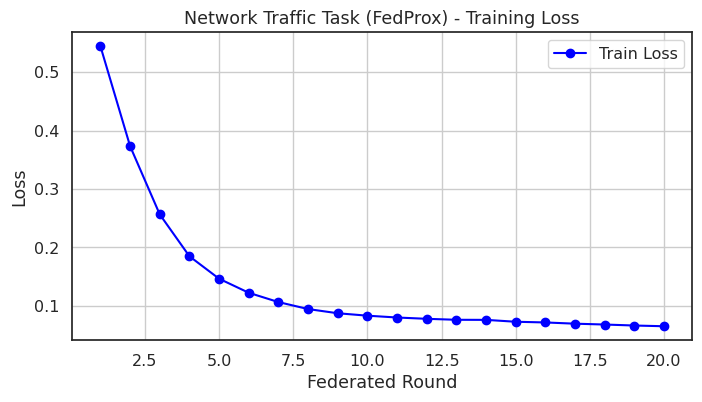

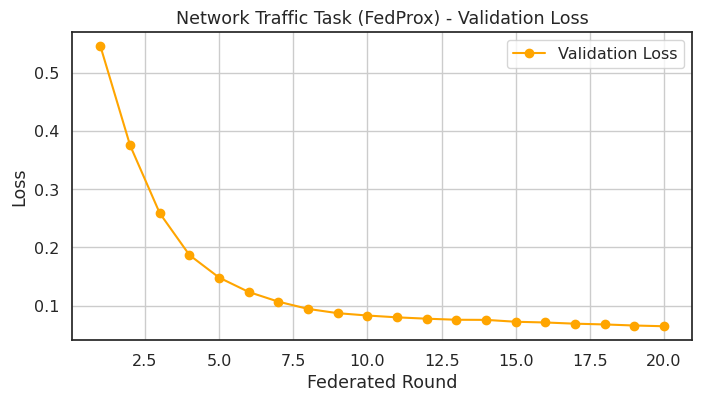

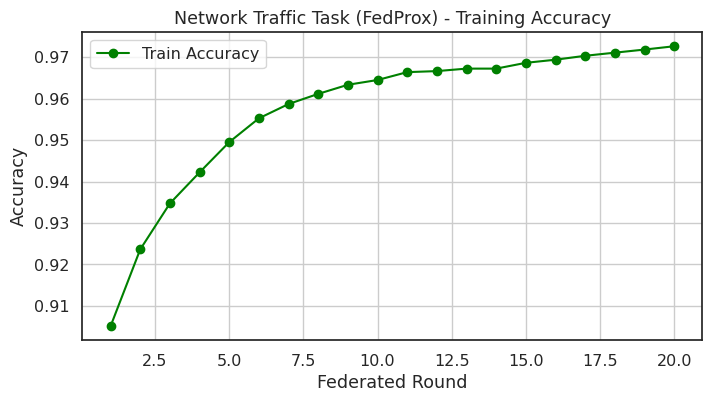

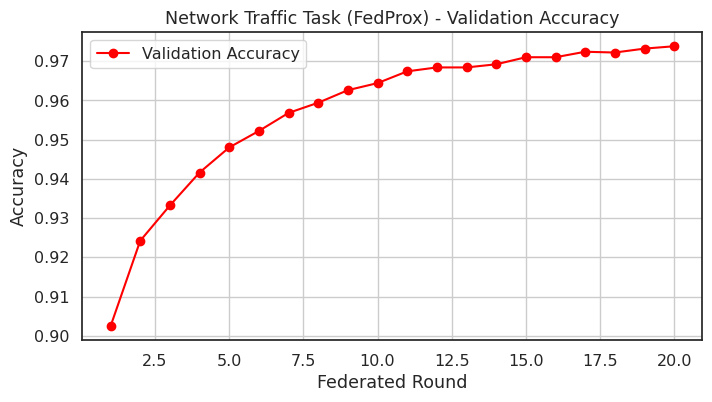

In [ ]:
print("Starting federated training for NETWORK TRAFFIC task (FedProx)...")

# Run federated training for network traffic using FedProx
global_model_traffic_trained, hist_traffic = federated_training_fedprox(
    global_model=global_model_traffic,
    client_loaders=client_loaders_traffic,
    input_dim=input_dim_traffic,
    num_classes=1,                 # Binary classification
    local_epochs=LOCAL_EPOCHS_TRAFFIC,
    rounds=FED_ROUNDS,
    mu=FEDPROX_MU
)

# ------------------- Plot Training Loss -------------------
plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['train_loss'],
         label='Train Loss', color='blue', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Network Traffic Task (FedProx) - Training Loss')
plt.legend()
plt.grid(True)
plt.show()

# ------------------- Plot Validation Loss -------------------
plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['val_loss'],
         label='Validation Loss', color='orange', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Network Traffic Task (FedProx) - Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# ------------------- Plot Training Accuracy -------------------
plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['train_acc'],
         label='Train Accuracy', color='green', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Network Traffic Task (FedProx) - Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ------------------- Plot Validation Accuracy -------------------
plt.figure(figsize=(8,4))
plt.plot(hist_traffic['round'], hist_traffic['val_acc'],
         label='Validation Accuracy', color='red', marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Network Traffic Task (FedProx) - Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Evaluating trained global model for NETWORK TRAFFIC task...")

X_test_traffic = []
y_test_traffic = []

# Collect test data from all clients
for _, test_loader in client_loaders_traffic:
    for xb, yb in test_loader:
        X_test_traffic.append(xb.numpy())
        y_test_traffic.append(yb.numpy())

X_test_traffic = np.vstack(X_test_traffic)
y_test_traffic = np.hstack(y_test_traffic)

# Create tf dataset for evaluation
test_dataset_traffic = tf.data.Dataset.from_tensor_slices(
    (X_test_traffic, y_test_traffic)
).batch(256)

# Evaluate
test_loss, test_acc, _ = evaluate_model_on_loader(
    global_model_traffic_trained,
    test_dataset_traffic
)

print(f"Overall NETWORK TRAFFIC Task - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# ---- Prediction probabilities ----
traffic_probs = global_model_traffic_trained.predict(X_test_traffic).flatten()

threshold = 0.5
traffic_preds = (traffic_probs >= threshold).astype(int)

print("\nSample predictions (0=Benign, 1=Malicious):")
for i in range(min(10, len(traffic_preds))):
    print(f"True: {y_test_traffic[i]}, Predicted: {traffic_preds[i]}")

unique, counts = np.unique(traffic_preds, return_counts=True)
print("\nPredicted class distribution:", dict(zip(unique, counts)))

Evaluating trained global model for NETWORK TRAFFIC task...
Overall NETWORK TRAFFIC Task - Test Loss: 0.0643, Test Accuracy: 0.9738
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Sample predictions (0=Benign, 1=Malicious):
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1
True: 1, Predicted: 1

Predicted class distribution: {np.int64(0): np.int64(1628), np.int64(1): np.int64(3374)}


In [ ]:
from sklearn.metrics import classification_report

print("Network Traffic Classification Report:\n")

print(classification_report(
    y_test_traffic,
    traffic_preds,
    target_names=["Benign", "Malicious"]
))

Network Traffic Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.97      0.96      1593
   Malicious       0.99      0.98      0.98      3409

    accuracy                           0.97      5002
   macro avg       0.97      0.97      0.97      5002
weighted avg       0.97      0.97      0.97      5002



In [ ]:
def federated_training_fedprox_gradient_metrics(
    global_model,
    client_loaders,
    input_dim,
    num_classes,
    local_epochs,
    rounds=FED_ROUNDS,
    mu=0.01
):

    history = {
        'round': [],
        'grad_norm': [],
        'grad_variance': [],
        'sudden_divergence': [],
        'recon_vulnerability': []
    }

    global_weights = global_model.get_weights()
    prev_grad_norm = None

    for r in range(1, rounds + 1):
        print(f"--- FedProx Round {r}/{rounds} ---")

        client_deltas = []
        grad_norms = []

        # ---- Local Training ----
        for train_loader, _ in client_loaders:

            updated_weights = local_train_fedprox(
                global_weights,
                train_loader,
                input_dim=input_dim,
                epochs=local_epochs,
                num_classes=num_classes,
                mu=mu
            )

            delta = [uw - gw for uw, gw in zip(updated_weights, global_weights)]
            client_deltas.append(delta)

            grad_norms.append(compute_gradient_norm(delta))

        # ---- FedProx Aggregation (Simple Average) ----
        new_weights = []

        for layer_idx in range(len(global_weights)):
            layer_updates = [delta[layer_idx] for delta in client_deltas]
            avg_update = np.mean(layer_updates, axis=0)
            new_weights.append(global_weights[layer_idx] + avg_update)

        global_weights = new_weights
        global_model.set_weights(global_weights)

        # ---- Gradient Metrics ----
        avg_grad_norm = np.mean(grad_norms)
        grad_variance = compute_gradient_variance(client_deltas)

        sudden_div = 0.0 if prev_grad_norm is None else abs(avg_grad_norm - prev_grad_norm)
        recon_proxy = reconstruction_vulnerability_proxy(avg_grad_norm, grad_variance)

        prev_grad_norm = avg_grad_norm

        history['round'].append(r)
        history['grad_norm'].append(avg_grad_norm)
        history['grad_variance'].append(grad_variance)
        history['sudden_divergence'].append(sudden_div)
        history['recon_vulnerability'].append(recon_proxy)

        print(
            f"Round {r} | "
            f"Grad Norm: {avg_grad_norm:.4f}, "
            f"Grad Var: {grad_variance:.6f}, "
            f"Divergence: {sudden_div:.4f}, "
            f"Recon Risk: {recon_proxy:.6f}"
        )

    return global_model, history

In [ ]:
print("Starting federated training for GRADIENT LEAKAGE (MNIST) task using FedProx...")

global_model_gradient_fedprox, hist_mnist_fedprox = (
    federated_training_fedprox_gradient_metrics(
        global_model_gradient,
        client_loaders_mnist,
        input_dim_gradient,
        num_classes=10,
        local_epochs=LOCAL_EPOCHS_MNIST,
        rounds=FED_ROUNDS,
        mu=0.01
    )
)

Starting federated training for GRADIENT LEAKAGE (MNIST) task using FedProx...
--- FedProx Round 1/20 ---
Round 1 | Grad Norm: 3.5053, Grad Var: 0.000072, Divergence: 0.0000, Recon Risk: 0.000251
--- FedProx Round 2/20 ---
Round 2 | Grad Norm: 2.7158, Grad Var: 0.000045, Divergence: 0.7894, Recon Risk: 0.000123
--- FedProx Round 3/20 ---
Round 3 | Grad Norm: 2.2537, Grad Var: 0.000035, Divergence: 0.4621, Recon Risk: 0.000078
--- FedProx Round 4/20 ---
Round 4 | Grad Norm: 2.0072, Grad Var: 0.000029, Divergence: 0.2466, Recon Risk: 0.000059
--- FedProx Round 5/20 ---
Round 5 | Grad Norm: 1.8585, Grad Var: 0.000026, Divergence: 0.1487, Recon Risk: 0.000048
--- FedProx Round 6/20 ---
Round 6 | Grad Norm: 1.7429, Grad Var: 0.000023, Divergence: 0.1155, Recon Risk: 0.000040
--- FedProx Round 7/20 ---
Round 7 | Grad Norm: 1.6573, Grad Var: 0.000021, Divergence: 0.0857, Recon Risk: 0.000035
--- FedProx Round 8/20 ---
Round 8 | Grad Norm: 1.5939, Grad Var: 0.000020, Divergence: 0.0634, Recon 

In [ ]:
final_recon_risk_fedprox = hist_mnist_fedprox['recon_vulnerability'][-1]

print(f"\nFinal Reconstruction Vulnerability (FedProx): {final_recon_risk_fedprox:.6f}")


Final Reconstruction Vulnerability (FedProx): 0.000016


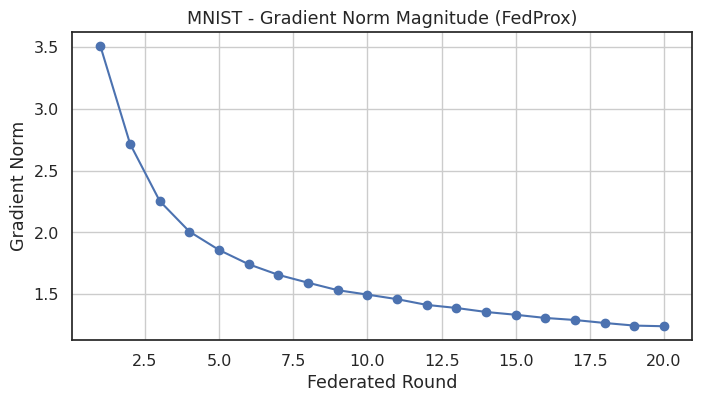

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist_fedprox['round'],
         hist_mnist_fedprox['grad_norm'],
         marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Gradient Norm')
plt.title('MNIST - Gradient Norm Magnitude (FedProx)')
plt.grid(True)
plt.show()

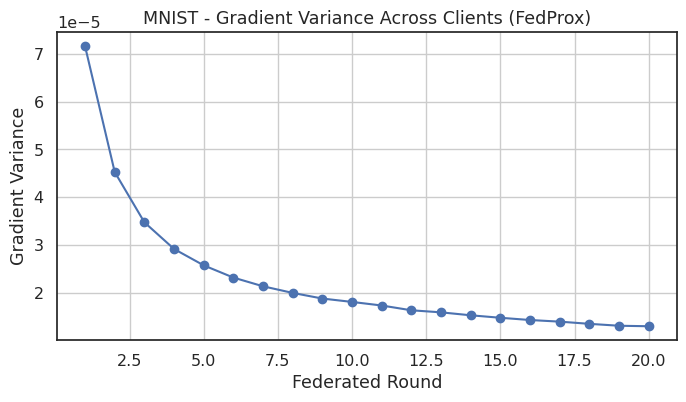

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist_fedprox['round'],
         hist_mnist_fedprox['grad_variance'],
         marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Gradient Variance')
plt.title('MNIST - Gradient Variance Across Clients (FedProx)')
plt.grid(True)
plt.show()

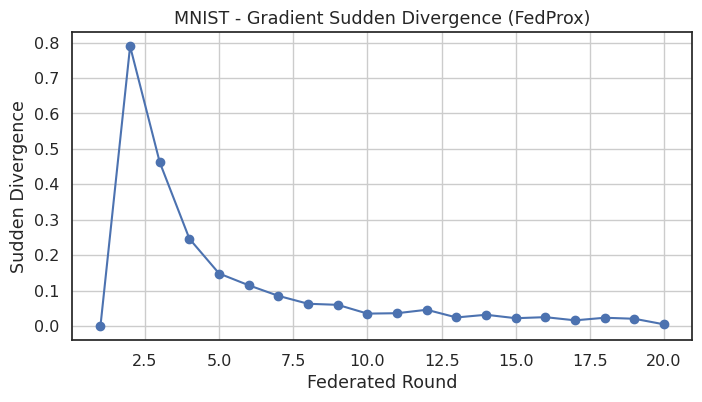

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist_fedprox['round'],
         hist_mnist_fedprox['sudden_divergence'],
         marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Sudden Divergence')
plt.title('MNIST - Gradient Sudden Divergence (FedProx)')
plt.grid(True)
plt.show()

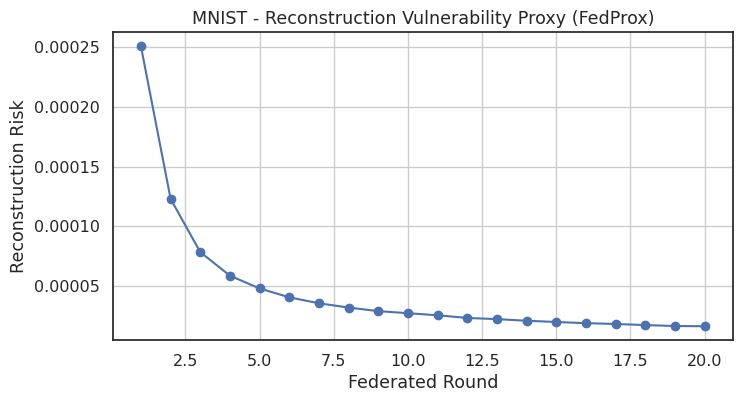

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_mnist_fedprox['round'],
         hist_mnist_fedprox['recon_vulnerability'],
         marker='o')
plt.xlabel('Federated Round')
plt.ylabel('Reconstruction Risk')
plt.title('MNIST - Reconstruction Vulnerability Proxy (FedProx)')
plt.grid(True)
plt.show()

In [ ]:
print("Evaluating trained global model for GRADIENT LEAKAGE (MNIST) task using FedProx...")

# Collect all test samples from clients
X_test_samples = []
y_test_samples = []

for _, test_loader in client_loaders_mnist:
    for xb, yb in test_loader:
        X_test_samples.append(xb)  # keep as TF tensors
        y_test_samples.append(yb)

X_test_samples = tf.concat(X_test_samples, axis=0)
y_test_samples = tf.concat(y_test_samples, axis=0)

# Evaluate the global model (FedProx trained)
test_loss, test_acc, total_samples = evaluate_model_on_loader(
    global_model_gradient_fedprox,
    tf.data.Dataset.from_tensor_slices(
        (X_test_samples, y_test_samples)
    ).batch(256)
)

print(f"Overall MNIST Task - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Multiclass prediction
mnist_probs = global_model_gradient_fedprox.predict(X_test_samples)
mnist_preds = np.argmax(mnist_probs, axis=1)

print("\nSample predictions (0–9 classes):")
for i in range(min(10, len(mnist_preds))):
    print(f"True: {int(y_test_samples[i])}, Predicted: {mnist_preds[i]}")

# Predicted class distribution
unique, counts = np.unique(mnist_preds, return_counts=True)
print("\nPredicted class distribution:", dict(zip(unique, counts)))

Evaluating trained global model for GRADIENT LEAKAGE (MNIST) task using FedProx...
Overall MNIST Task - Test Loss: 0.2191, Test Accuracy: 0.9352
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step

Sample predictions (0–9 classes):
True: 2, Predicted: 2
True: 7, Predicted: 7
True: 0, Predicted: 0
True: 7, Predicted: 7
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 7, Predicted: 7
True: 7, Predicted: 7
True: 0, Predicted: 0
True: 2, Predicted: 2

Predicted class distribution: {np.int64(0): np.int64(1449), np.int64(1): np.int64(1568), np.int64(2): np.int64(1367), np.int64(3): np.int64(1498), np.int64(4): np.int64(1195), np.int64(5): np.int64(981), np.int64(6): np.int64(1369), np.int64(7): np.int64(1522), np.int64(8): np.int64(1499), np.int64(9): np.int64(1548)}


In [ ]:
from sklearn.metrics import classification_report

print("MNIST Classification Report:\n")

print(classification_report(
    y_test_samples.numpy(),   # convert tensor to numpy
    mnist_preds,
    target_names=[str(i) for i in range(10)]
))

MNIST Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1420
           1       0.97      0.98      0.98      1555
           2       0.97      0.92      0.95      1439
           3       0.90      0.93      0.92      1442
           4       0.96      0.85      0.90      1341
           5       0.99      0.77      0.87      1260
           6       0.95      0.97      0.96      1346
           7       0.93      0.98      0.95      1436
           8       0.88      0.98      0.93      1339
           9       0.87      0.95      0.91      1418

    accuracy                           0.94     13996
   macro avg       0.94      0.93      0.93     13996
weighted avg       0.94      0.94      0.93     13996



In [ ]:
print("Performing FINAL SYSTEM-LEVEL SAFETY EVALUATION...")

# Convert multiclass MNIST predictions to binary flags (malicious if any high probability class)
mnist_flags = (np.max(mnist_probs, axis=1) >= 0.5).astype(int)

# If any threat model predicts malicious samples → UNSAFE
phish_attack_detected = np.any(phish_preds == 1)
traffic_attack_detected = np.any(traffic_preds == 1)
mnist_attack_detected = np.any(mnist_flags == 1)

print("\nThreat Detection Summary:")
print(f"Phishing Threat Detected: {phish_attack_detected}")
print(f"Traffic Threat Detected: {traffic_attack_detected}")
print(f"Gradient Leakage Detected: {mnist_attack_detected}")

# Final system decision
final_system_status = "UNSAFE" if (phish_attack_detected or traffic_attack_detected or mnist_attack_detected) else "SAFE"

print("\n==============================")
print(f"FINAL SYSTEM STATUS: {final_system_status}")

Performing FINAL SYSTEM-LEVEL SAFETY EVALUATION...

Threat Detection Summary:
Phishing Threat Detected: True
Traffic Threat Detected: True
Gradient Leakage Detected: True

FINAL SYSTEM STATUS: UNSAFE


In [ ]:
import os

save_dir = "saved_federated_models" os.makedirs(save_dir, exist_ok=True)

In [ ]:

fedavgpp_path_h5 = os.path.join(save_dir, "mnist_fedavgpp_model.h5")
global_model_gradient_trained.save(fedavgpp_path_h5)

fedavgpp_path_tf = os.path.join(save_dir, "mnist_fedavgpp_savedmodel")
global_model_gradient_trained.save(fedavgpp_path_tf)

print("FedAvg++ model saved successfully!")

In [ ]:

fedprox_path_h5 = os.path.join(save_dir, "mnist_fedprox_model.h5")
global_model_gradient_fedprox.save(fedprox_path_h5)


fedprox_path_tf = os.path.join(save_dir, "mnist_fedprox_savedmodel")
global_model_gradient_fedprox.save(fedprox_path_tf)

print("FedProx model saved successfully!")

In [ ]:
from tensorflow.keras.models import load_model

fedavgpp_loaded = load_model("saved_federated_models/mnist_fedavgpp_model.h5")
fedprox_loaded = load_model("saved_federated_models/mnist_fedprox_model.h5")

print("Models loaded successfully!")